# INN Hotels Project

## Context

A significant number of hotel bookings are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impact a hotel on various fronts:
* Loss of resources (revenue) when the hotel cannot resell the room.
* Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
* Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
* Human resources to make arrangements for the guests.

## Objective
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

## Data Description
The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.


**Data Dictionary**

* Booking_ID: unique identifier of each booking
* no_of_adults: Number of adults
* no_of_children: Number of Children
* no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
* type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
* room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
* lead_time: Number of days between the date of booking and the arrival date
* arrival_year: Year of arrival date
* arrival_month: Month of arrival date
* arrival_date: Date of the month
* market_segment_type: Market segment designation.
* repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
* no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
* no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
* avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* booking_status: Flag indicating if the booking was canceled or not.

## Importing necessary libraries and data

In [ ]:
# Installing the libraries with the specified version.
!pip install pandas==1.5.3 numpy==1.25.2 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 statsmodels==0.14.1 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 37.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# Libraries to help with reading and manipulating data

import pandas as pd
import numpy as np

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)


# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    ConfusionMatrixDisplay,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

In [ ]:
# Loading the dataset
hotel = pd.read_csv("INNHotelsGroup.csv")

In [ ]:
# copying data to another variable to avoid any changes to original data
data = hotel.copy()

## Data Overview

- Observations
- Sanity checks

In [ ]:
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


Dataset contains informations about the different customers. There is not missing values in first five rows.

In [ ]:
data.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled


In both first and last five rows, there was zero number of children in the data set.

In [ ]:
data.shape

(36275, 19)

There are total 36,275 rows and 19 columns in dataset.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

There are 5 object datatype columns, and 14 numerical columns.

In [ ]:
data.duplicated().sum()

np.int64(0)

There are no duplicates in the dataset.

In [ ]:
data.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


There is no missing values in dataset.

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0




*   Mean for the number of adults column is approx 2 and the median is 2. This shows that majority of the customers who stayed at the hotel.

*   Mean for the number of children column is approx 0 and the median is 0. This shows that there is nearly zero children who stayed in the hotel.
*   The mean of Average price per room  is approx 103 euros but it has a wide range with values from 0 to 540 euros. We will explore this further in univariate analysis.
*   Mean lead time for the customers who booked(room) date to arrival date is about 3 months (85 days).
*   Average number of previous booking cancellations is a 0.023 times by the customers who cancelled their booking before making the current booking.
*   Average number of previous booking not canceled is 0.15 times by the customers previously made bookings in past that they did not cancel prior to their current booking.



## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**:
1. What are the busiest months in the hotel?
2. Which market segment do most of the guests come from?
3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?
4. What percentage of bookings are canceled?
5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?
6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
df = data.copy()

###Univariate Analysis

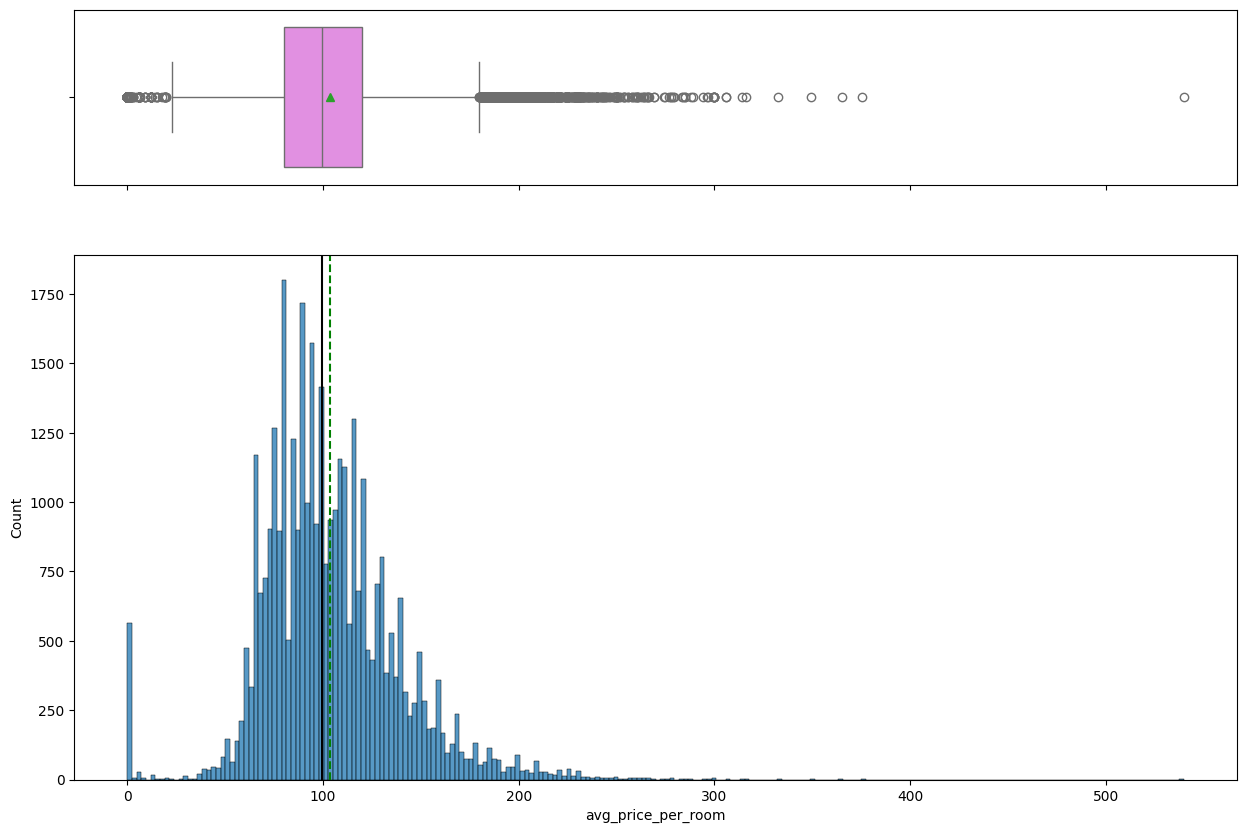

In [ ]:
histogram_boxplot(df, 'avg_price_per_room')

The mean of average price per room is 103 euros. The median of average price per room is very close to 100 euros. It implies that the half of average pride per room is less than median, and other half is more than median price.

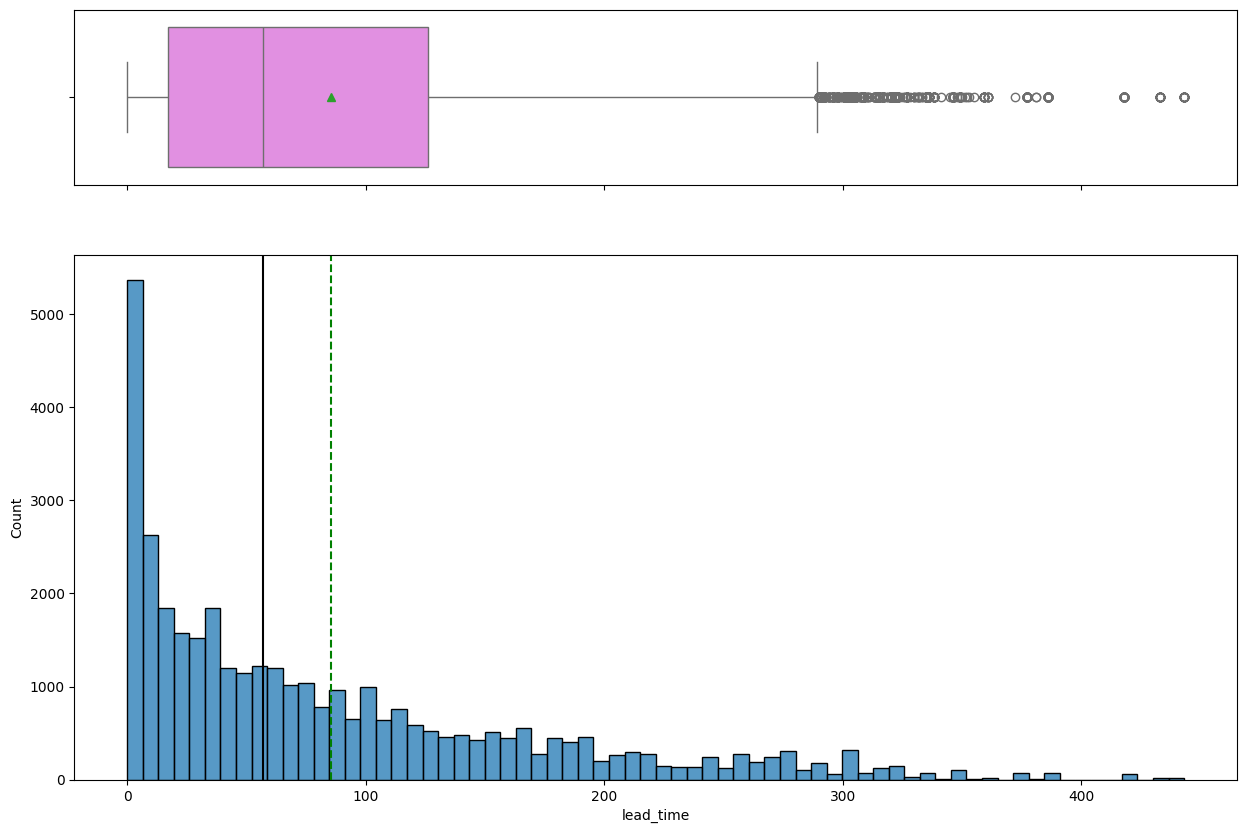

In [ ]:
histogram_boxplot(df, 'lead_time')

The average number of days between the date of booking and the arrival date is about 85 days.
The median lead time is 57 days. It implies that half the lead time is less than the median, and the other half of the lead time more than the median.

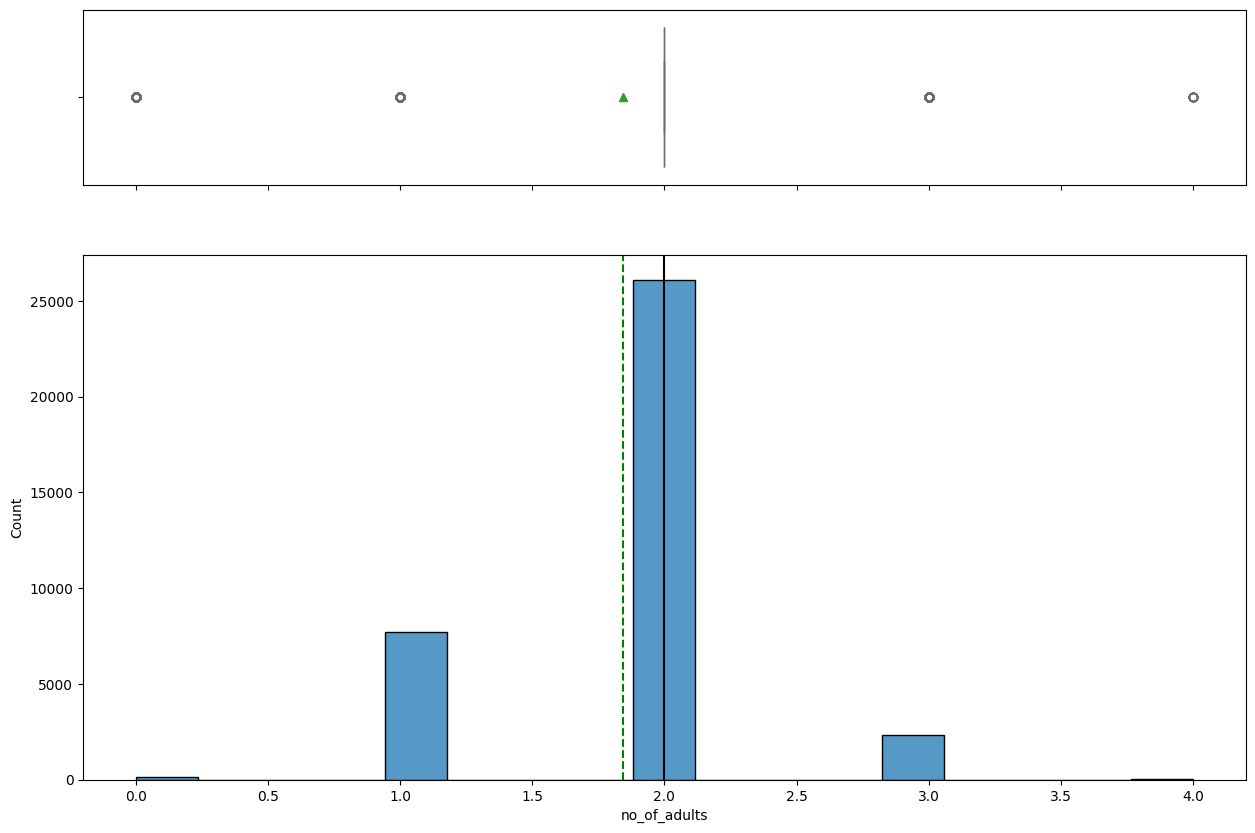

In [ ]:
histogram_boxplot(df, 'no_of_adults')

The average number of adults is about 1.8 at INN hotels.
The median of number of adults is 2 adults. It implies that half number of adults is less than the median, and the other half of the number of adults is more than the median.

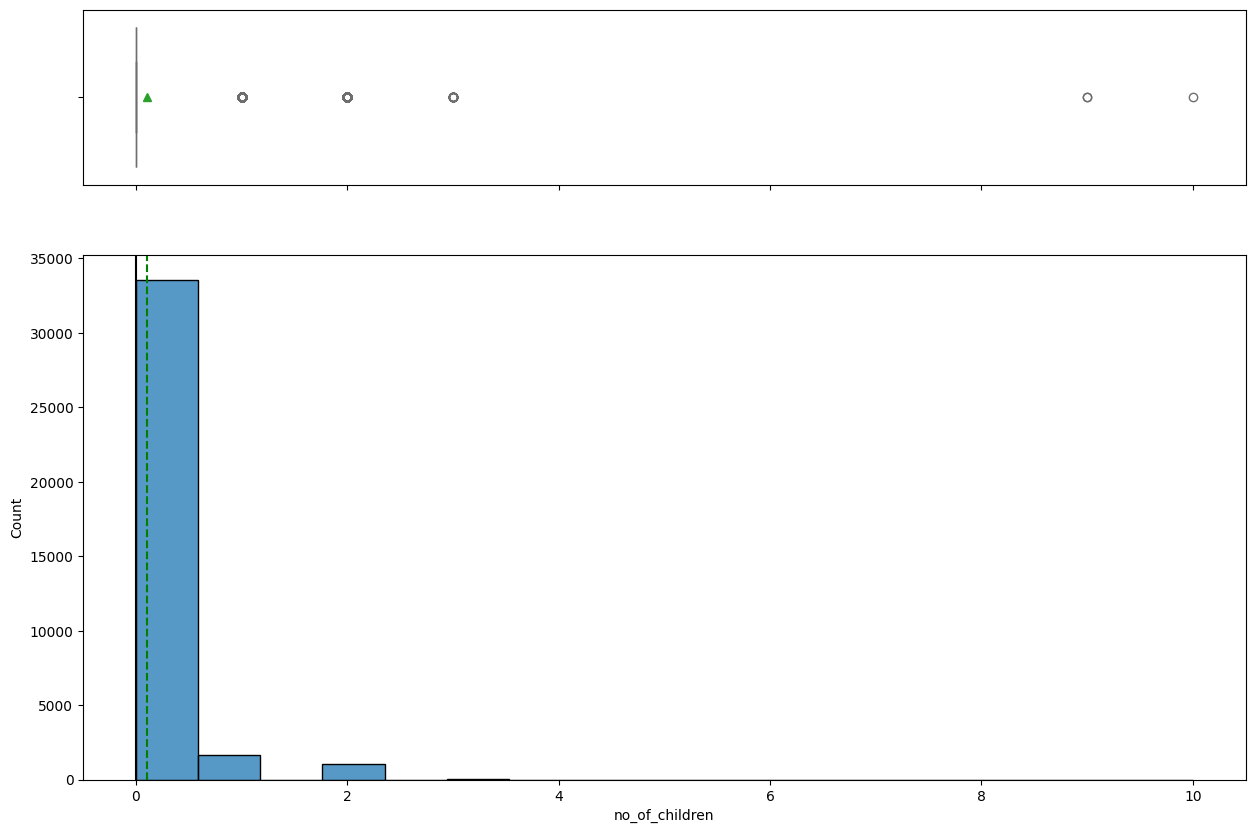

In [ ]:
histogram_boxplot(df, 'no_of_children')

The average number of children is little over zero at INN hotels.
The median of number of children is zero. It implies that half number of children is less than the median, and the other half of the number of children is more than the median.

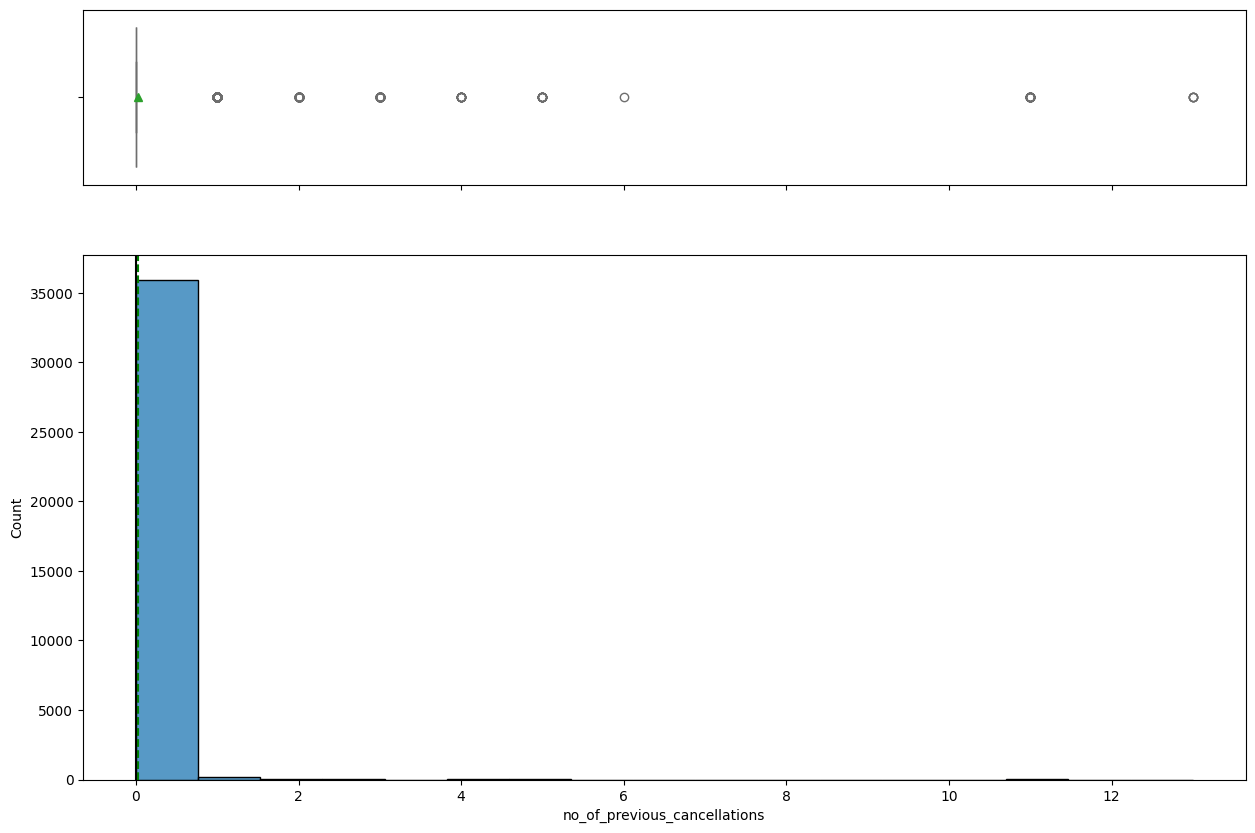

In [ ]:
histogram_boxplot(df, 'no_of_previous_cancellations')

The average number of previous bookings that were canceled by the customer prior to the current booking is about zero times.
The median of number of previous cancellations happened prior to the current booking by customer is exact zero. This implies that at least half of the customers had zero previous cancellations prior to their current booking. And, the other half of the customers had more than zero previous cancellations priror to their current booking.

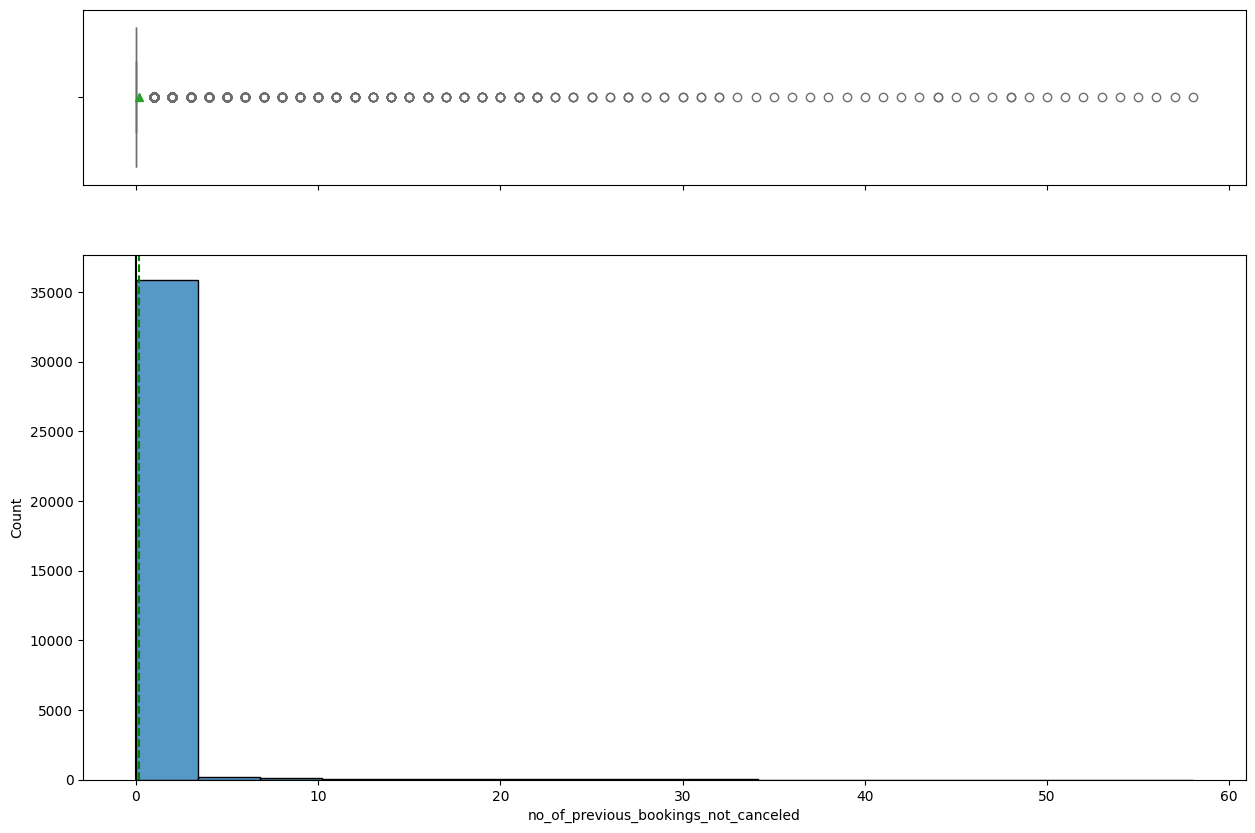

In [ ]:
histogram_boxplot(df, 'no_of_previous_bookings_not_canceled')

The average number of previous bookings that not canceled by the customer prior to the current booking is close to zero times.
The median of number of previous bookings not canceled by the customer prior to the current booking is exact zero. This implies that at least half of the customers had zero previous bookings that were not canceled prior to their current booking. The remaining customers had more than zero previous bookings that were not cancelled.


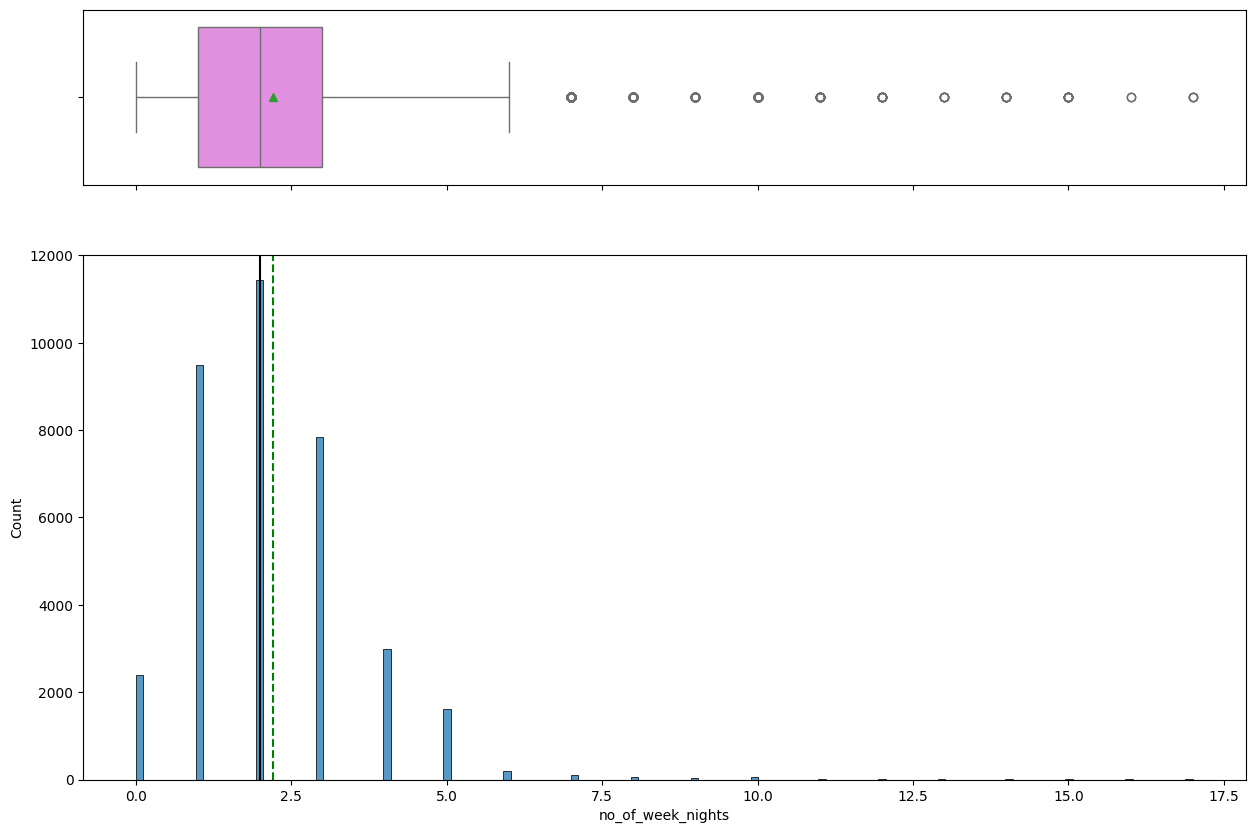

In [ ]:
histogram_boxplot(df, 'no_of_week_nights')

The average number of week nights is about 2 nights that guest stayed or booked at INN hotels.
The median of week nights is 2 nights. It implies that half the week nights is less than the median, and the other half of the week nights more than the median.

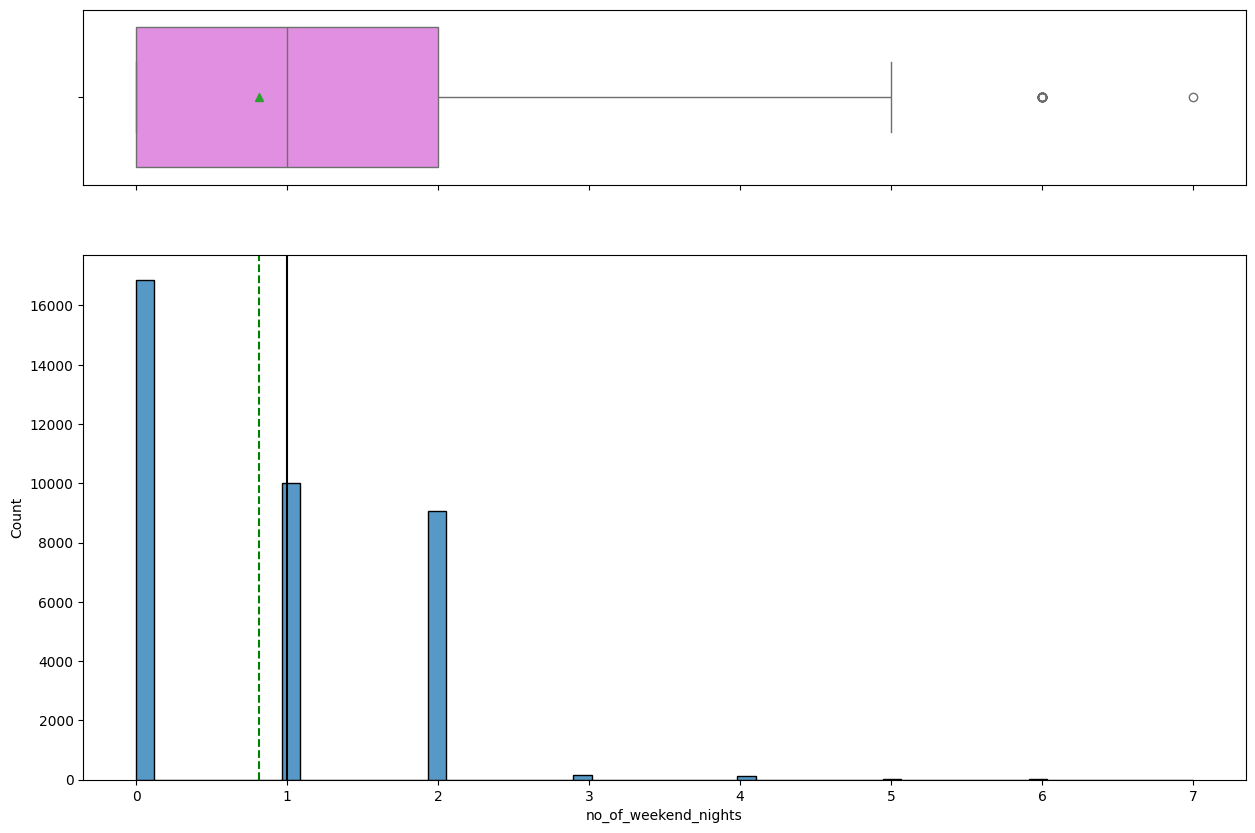

In [ ]:
histogram_boxplot(df, 'no_of_weekend_nights')

The average number of weekend nights is about less than 1 night that guest stayed or booked at INN hotel.
The median of week nights is 1 night. It implies that half the weekend nights is less than the median, and the other half of the weekend nights more than the median.

arrival_month
10    14.657478
9     12.711234
8     10.511371
6      8.829773
12     8.328050
11     8.215024
7      8.049621
4      7.542385
5      7.161957
3      6.500345
2      4.697450
1      2.795314
Name: proportion, dtype: float64


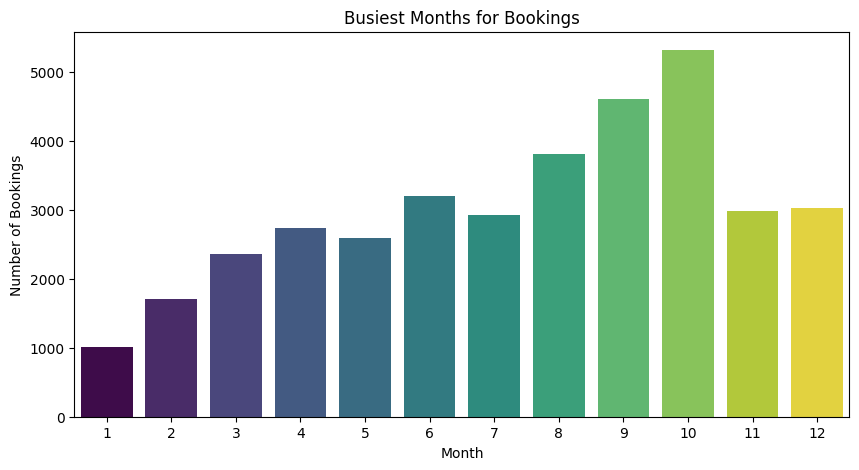

In [ ]:
print(df['arrival_month'].value_counts(normalize=True)*100)

# Visualization
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='arrival_month', palette='viridis', hue='arrival_month', legend=False)
plt.title('Busiest Months for Bookings')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.show()

October has the highest percentage of bookings (14.65%), followed by September(12.71%) and August (10.51%). January has the lowest percetange of bookings (2.79%).


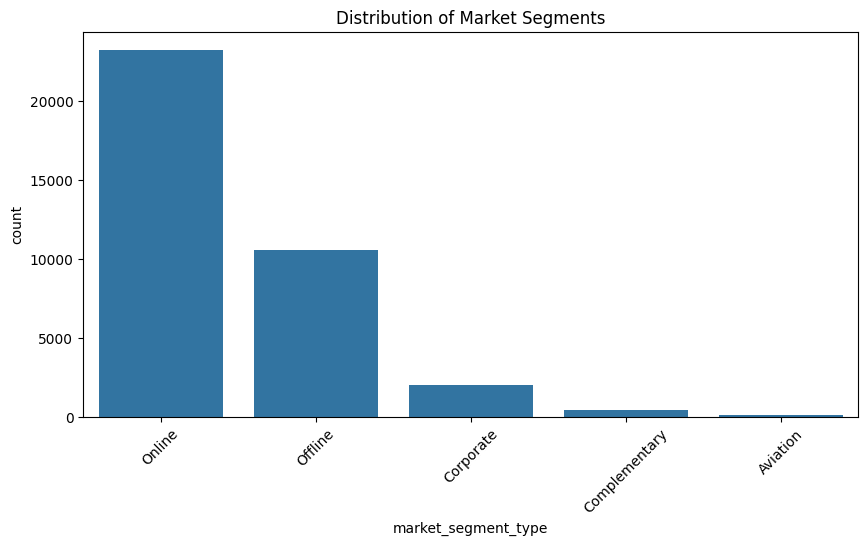

In [ ]:
# Visualization
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='market_segment_type', order=data['market_segment_type'].value_counts().index)
plt.title('Distribution of Market Segments')
plt.xticks(rotation=45)
plt.show()

The online market segment is the most dominate along with offine, corporate,complementary, and aviation that guests come from.

Cancellation Percentage:
booking_status
Not_Canceled    67.236389
Canceled        32.763611
Name: proportion, dtype: float64


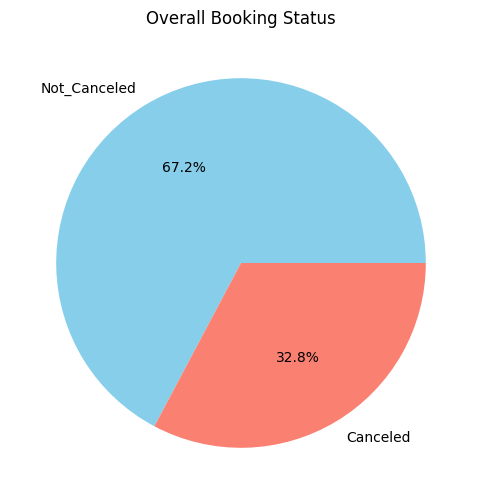

In [ ]:
# Calculation: Overall cancellation rate
cancellation_perc = df['booking_status'].value_counts(normalize=True) * 100
print(f"Cancellation Percentage:\n{cancellation_perc}")

# Visualization
plt.figure(figsize=(6, 6))
df['booking_status'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Overall Booking Status')
plt.ylabel('')
plt.show()

There about 33% of bookings are canceled by the guests.

###Bivariate Analysis

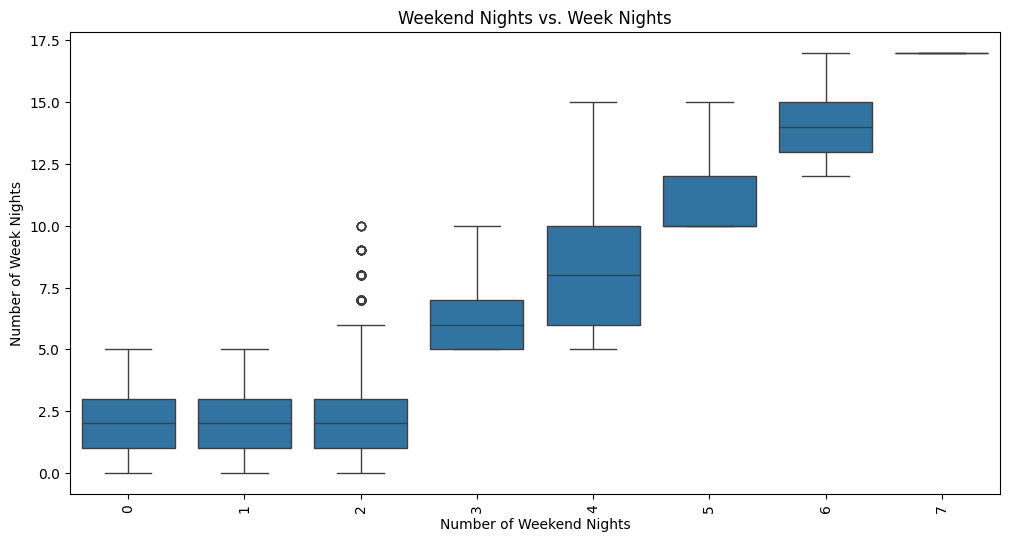

In [ ]:
# Visulization
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='no_of_weekend_nights', y='no_of_week_nights')
plt.title('Weekend Nights vs. Week Nights')
plt.xlabel('Number of Weekend Nights')
plt.ylabel('Number of Week Nights')
plt.xticks(rotation=90) # Rotate x-axis labels
plt.show()

This plot shows how many week nights people usually book, depending on how many weekend nights they also book.

When comparing the boxplots for **0, 1, or 2 weekend nights** with those for **4, 5, or 6 weekend nights**, we can observe the following:

*   **For 0, 1, or 2 weekend nights:** The boxes are lower, indicating that most guests booking a few weekend nights tend to book a lower number of week nights.
*   **For 4, 5, or 6 weekend nights:** The boxes are shifted upwards and little wider, suggesting that guests who book more weekend nights (like 4, 5, or 6) tend to stay for a higher number of week nights as well. This suggests longer overall stays for guests who Thisinclude more weekend nights.

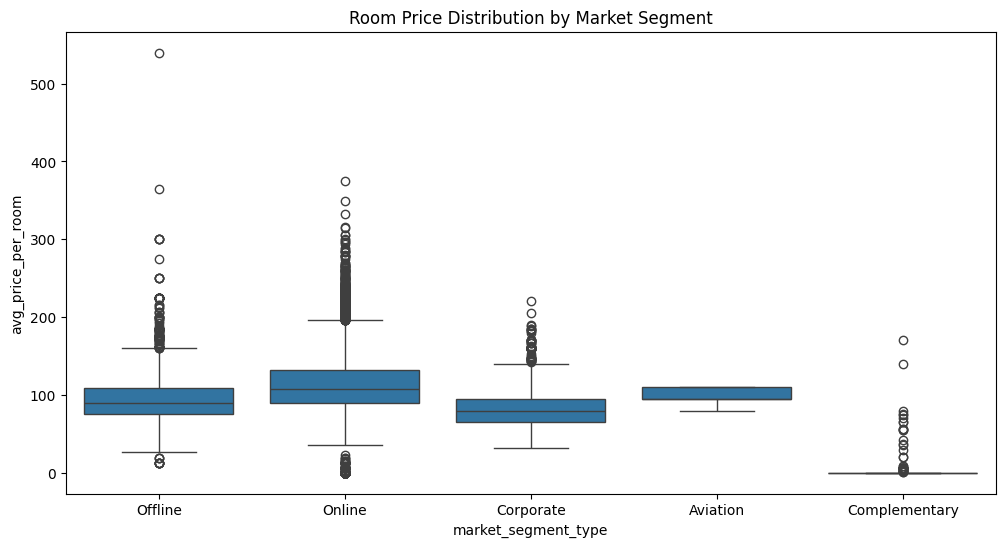

In [ ]:
# Visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='market_segment_type', y='avg_price_per_room')
plt.title('Room Price Distribution by Market Segment')
plt.show()

The online segment has a wider range from approximately 0 to 395 euros average price per room compare to corporate (approximately range from 50 to 220) in average price per room in euroes.

booking_status   Canceled  Not_Canceled
repeated_guest                         
0               33.580422     66.419578
1                1.720430     98.279570


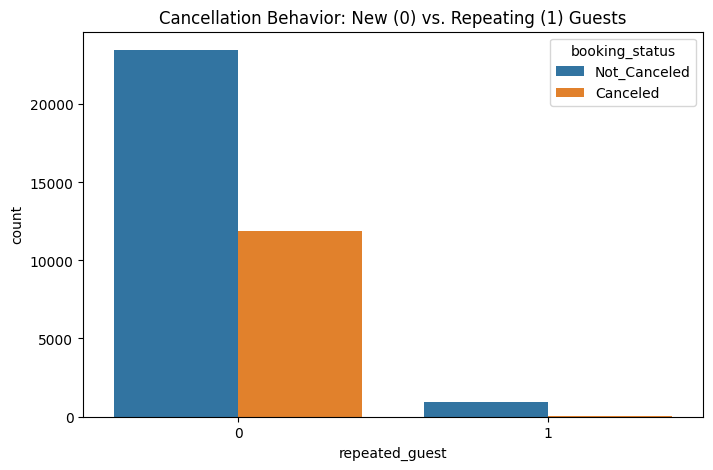

In [ ]:
# Calculation: Cancellation rate for new vs. repeating guests
rep_guest_cancellation = df.groupby('repeated_guest')['booking_status'].value_counts(normalize=True).unstack() * 100
print(rep_guest_cancellation)

# Visualization
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='repeated_guest', hue='booking_status')
plt.title('Cancellation Behavior: New (0) vs. Repeating (1) Guests')
plt.show()

The repeated_guest have a significantly lower cancellation than the new guest. The new guest have a much higher cancellation as seen in the countplot.

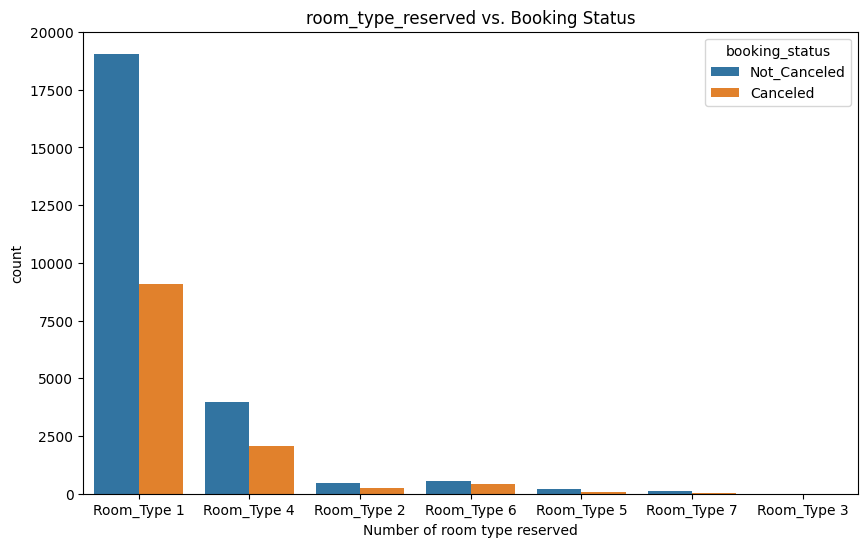

In [ ]:
# Visualization
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='room_type_reserved', hue='booking_status')
plt.title('room_type_reserved vs. Booking Status')
plt.xlabel('Number of room type reserved')
plt.show()

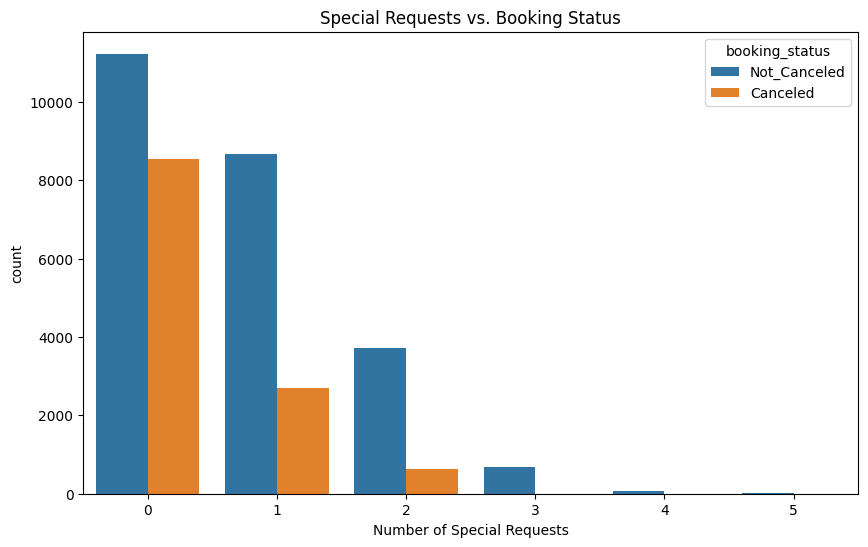

In [ ]:
# Visualization
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='no_of_special_requests', hue='booking_status')
plt.title('Special Requests vs. Booking Status')
plt.xlabel('Number of Special Requests')
plt.show()

The more a guest customizes their stay, the more likely they are to show up. This behaviour shows in the graph that canceled bar gets shrinks as the number of special requests increases.

### Correlation Heatmap

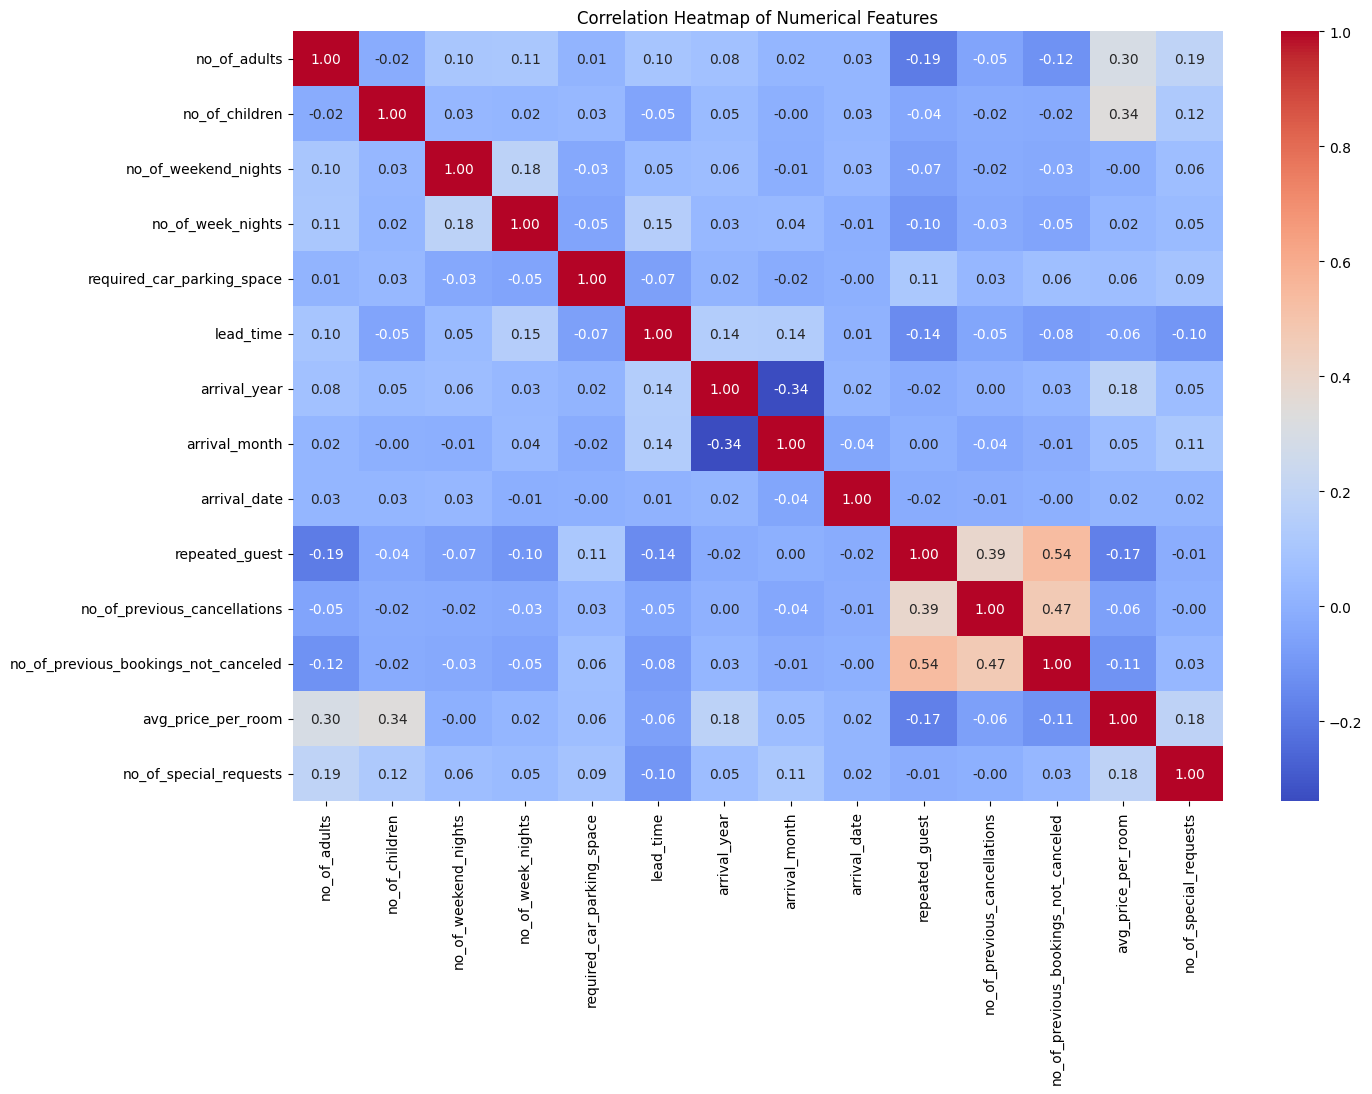

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)


###Missing value treatment (if needed)


There is no missing values in dataset. So, There is no need for missing values treatment.

####Feature engineering (if needed)


I prefer to keep the data as simple as possible not combining features for model building.

###Outlier detection and treatment (if needed)


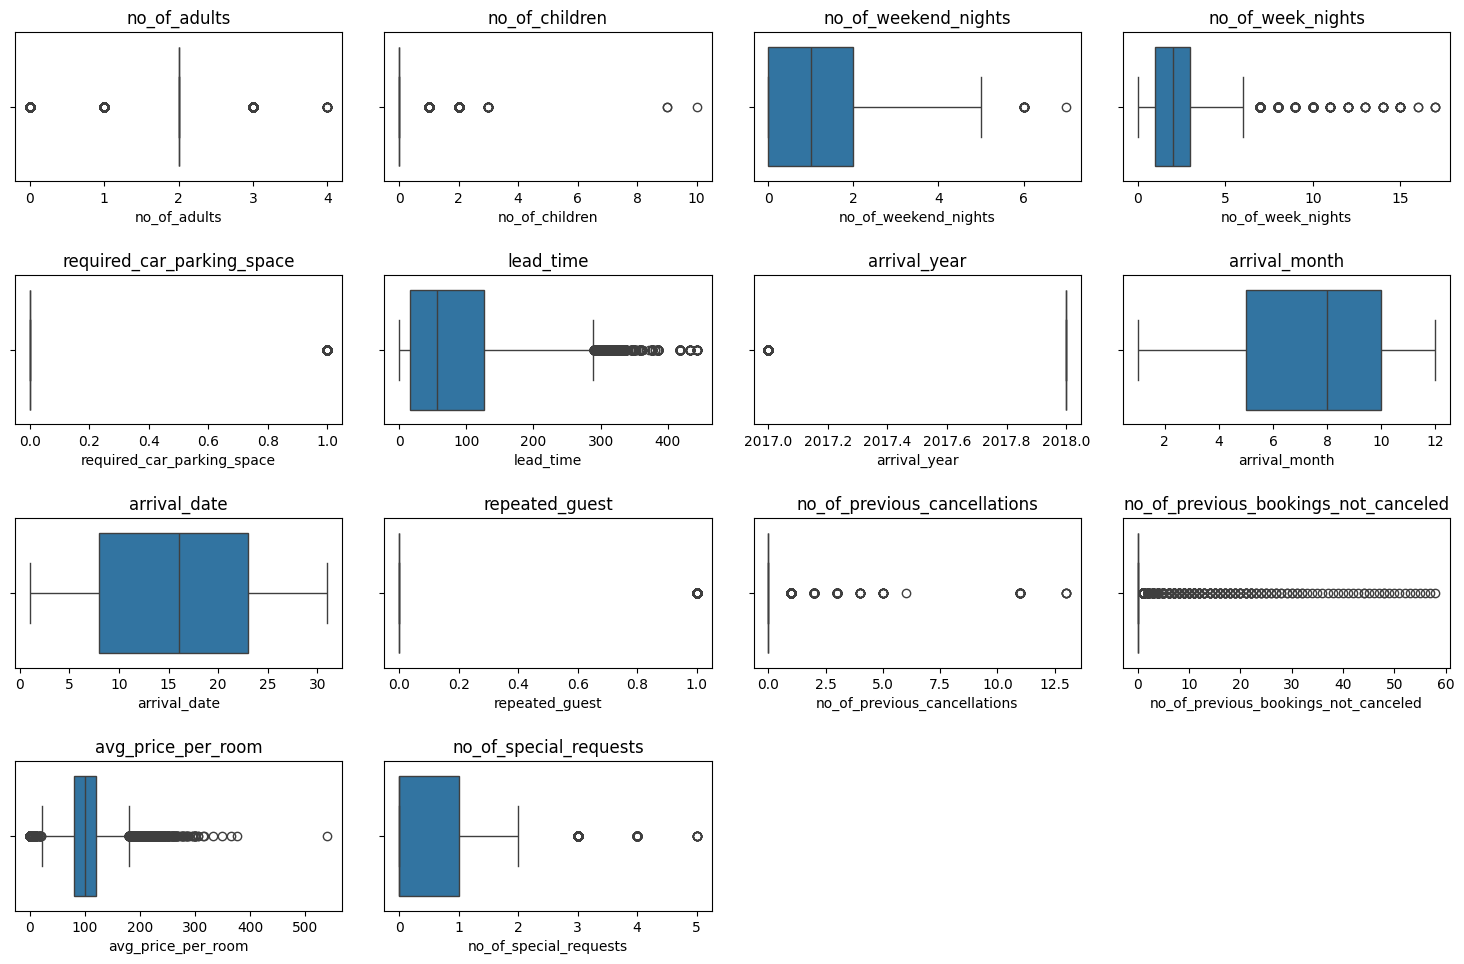

In [ ]:
# Outlier detection using boxplot
num_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)  # 4 rows, 4 columns, current subplot
    sns.boxplot(data=df, x=col)
    plt.title(col) # Add title for better readability
    plt.tight_layout(pad=2)

plt.show()

"Outlier treatment was not performed on continuous variables like avg_price_per_room and lead_time because the proximity of their means and medians suggests no heavy skewness. Furthermore, these extreme values represent legitimate business scenarios—such as seasonal peak pricing and long-range planning—which are essential for the model to capture real-world booking behavior. Although Logistic Regression can be sensitive to outliers, treatment was performed on avg_price_per_room and lead_time to preserve the integrity of legitimate business variations, such as peak-season pricing and early bookings.

####Preparing data for modeling


In [ ]:
# Create a working copy of the original data to avoid modifying it directly
df_model = data.copy()

# 1. Encode the target variable
df_model['booking_status'] = df_model['booking_status'].apply(lambda x: 1 if x == 'Canceled' else 0)

# 2. Drop the unique identifier
if 'Booking_ID' in df_model.columns:
    df_model = df_model.drop(['Booking_ID'], axis=1)

# 3. Create dummy variables and convert to 1s and 0s
df_model = pd.get_dummies(
    df_model,
    columns=['type_of_meal_plan', 'room_type_reserved', 'market_segment_type'],
    drop_first=True
).astype(float) # This replaces True/False with 1/0

In [ ]:
# to check target variable converted binary variable
df_model['booking_status'].value_counts(normalize=True)

,proportion
booking_status,
0.0,0.672364
1.0,0.327636


There were approximately 33% booking was cancelled. Also, the booking that was not canceled(67%).

In [ ]:
# 1. Define features (X) and target (y)
X = df_model.drop(['booking_status'], axis=1) # Ensure uppercase X
y = df_model['booking_status']

# 2. Add the constant for statsmodels intercept
X = sm.add_constant(X)

# 3. Split the data (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1, stratify=y)

## EDA

- It is a good idea to explore the data once again after manipulating it.

In [ ]:
# to check dummy vairables converted binary variable
df_model.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2.0,0.0,1.0,2.0,0.0,224.0,2017.0,10.0,2.0,0.0,0.0,0.0,65.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2.0,0.0,2.0,3.0,0.0,5.0,2018.0,11.0,6.0,0.0,0.0,0.0,106.68,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,2.0,1.0,0.0,1.0,2018.0,2.0,28.0,0.0,0.0,0.0,60.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2.0,0.0,0.0,2.0,0.0,211.0,2018.0,5.0,20.0,0.0,0.0,0.0,100.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2.0,0.0,1.0,1.0,0.0,48.0,2018.0,4.0,11.0,0.0,0.0,0.0,94.50,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Checking Multicollinearity

- In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Function to calculate VIF
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["Feature"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif.sort_values(by="VIF", ascending=False)

# Check VIF on your training features
print(calculate_vif(X_train))

                                 Feature           VIF
0                                  const  3.959545e+07
27            market_segment_type_Online  6.947183e+01
26           market_segment_type_Offline  6.251301e+01
25         market_segment_type_Corporate  1.663442e+01
24     market_segment_type_Complementary  4.350047e+00
13                    avg_price_per_room  2.032631e+00
2                         no_of_children  2.007213e+00
22        room_type_reserved_Room_Type 6  1.990106e+00
10                        repeated_guest  1.750194e+00
12  no_of_previous_bookings_not_canceled  1.570863e+00
7                           arrival_year  1.433261e+00
6                              lead_time  1.401920e+00
20        room_type_reserved_Room_Type 4  1.355784e+00
1                           no_of_adults  1.345059e+00
11          no_of_previous_cancellations  1.322011e+00
17        type_of_meal_plan_Not Selected  1.279209e+00
8                          arrival_month  1.277398e+00
15        

## Building a Logistic Regression model

In [ ]:
# Build and fit the model in one step
logit_model = sm.Logit(y_train, X_train.astype(float))
lm=logit_model.fit()

# Print the summary
print(lm.summary())

         Current function value: 0.422351
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25364
Method:                           MLE   Df Model:                           27
Date:                Sun, 31 May 2026   Pseudo R-squ.:                  0.3322
Time:                        03:12:22   Log-Likelihood:                -10724.
converged:                      False   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -886.9563    121.332     -7.310      0.000   -1124.762

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


##Checking model perfomance

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
# defining a function to plot the confusion_matrix of a classification model


def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

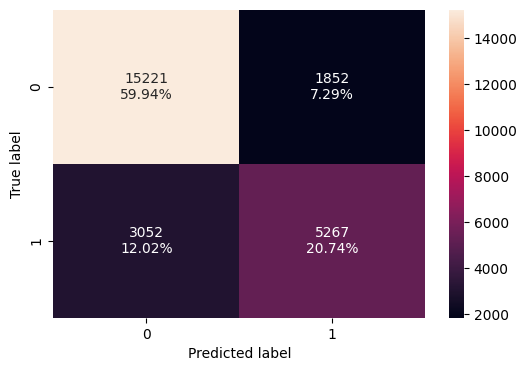

In [ ]:
confusion_matrix_statsmodels(lm, X_train, y_train)

In [ ]:
print('Training performance')
model_performance_classification_statsmodels(lm, X_train, y_train)

Training performance


,Accuracy,Recall,Precision,F1
0,0.806868,0.633129,0.739851,0.682342




*   The f1_score of the model is ~0.68 and we will try to maximize it further.
*   The variables used to build the model might contain multicollinearity, which will affect the p-values
*   We will have to remove multicollinearity from the data to get reliable coefficients and p-values




In [ ]:
#vif series before feature selection
vif_series=pd.Series([variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])], index=X_train.columns, dtype=float,)
print('VIF values: \n\n{}\n'.format(vif_series))

VIF values: 

const                                   3.959545e+07
no_of_adults                            1.345059e+00
no_of_children                          2.007213e+00
no_of_weekend_nights                    1.067255e+00
no_of_week_nights                       1.094373e+00
required_car_parking_space              1.034943e+00
lead_time                               1.401920e+00
arrival_year                            1.433261e+00
arrival_month                           1.277398e+00
arrival_date                            1.007629e+00
repeated_guest                          1.750194e+00
no_of_previous_cancellations            1.322011e+00
no_of_previous_bookings_not_canceled    1.570863e+00
avg_price_per_room                      2.032631e+00
no_of_special_requests                  1.247233e+00
type_of_meal_plan_Meal Plan 2           1.261818e+00
type_of_meal_plan_Meal Plan 3           1.007964e+00
type_of_meal_plan_Not Selected          1.279209e+00
room_type_reserved_Room_Type 2  

 The constant has an extremely high VIF value (~ 3.959545e+07), which is common when a constant is added and othere highly correlated dummy variables are present. The present of multicollinearity in market_segment_type of online(VIF~69.47), offine(VIF~62.51), and corporate(VIF~16.63). Market_segment _type of all dummies shows amonge high multicollinearity. These market segment type correlated varibles will drop one by one.

In [ ]:
#Removing market_segment_type_online

X_train1 = X_train.drop('market_segment_type_Online', axis=1)

vif_series2 = pd.Series(
    [variance_inflation_factor(X_train1.values, i) for i in range(X_train1.shape[1])],
    index=X_train1.columns,
)
print("VIF values: \n\n{}\n".format(vif_series2))

VIF values: 

const                                   3.951065e+07
no_of_adults                            1.328675e+00
no_of_children                          2.006306e+00
no_of_weekend_nights                    1.066891e+00
no_of_week_nights                       1.093767e+00
required_car_parking_space              1.034859e+00
lead_time                               1.397513e+00
arrival_year                            1.430535e+00
arrival_month                           1.276289e+00
arrival_date                            1.007598e+00
repeated_guest                          1.747050e+00
no_of_previous_cancellations            1.321916e+00
no_of_previous_bookings_not_canceled    1.570529e+00
avg_price_per_room                      2.031834e+00
no_of_special_requests                  1.242437e+00
type_of_meal_plan_Meal Plan 2           1.261488e+00
type_of_meal_plan_Meal Plan 3           1.007964e+00
type_of_meal_plan_Not Selected          1.277105e+00
room_type_reserved_Room_Type 2  

By removing market segment type online, other dummi variables such as market segment type offline, market segment type corporate has improved VIF score market segment type offline(1.60), market segment corporate(1.53). So, no need to drop these features further now.

In [ ]:
logit_model2= sm.Logit(y_train, X_train1.astype(float))
lm2 = logit_model2.fit(disp=False)

print("Training performance:")
model_performance_classification_statsmodels(lm2, X_train1, y_train)

Training performance:


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Accuracy,Recall,Precision,F1
0,0.806868,0.633129,0.739851,0.682342


In [ ]:
#removing high p-values
# initial list of columns
cols = X_train1.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    X_train_aux = X_train1[cols]

    # fitting the model
    model = sm.Logit(y_train, X_train_aux).fit(disp=False)

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


['const', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'repeated_guest', 'no_of_previous_cancellations', 'avg_price_per_room', 'no_of_special_requests', 'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 4', 'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 7', 'market_segment_type_Corporate', 'market_segment_type_Offline']


In [ ]:
X_train2 = X_train1[selected_features]

In [ ]:
logit_model3=sm.Logit(y_train, X_train2.astype(float))
lm3=logit_model3.fit(disp=False)
print(lm3.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25372
Method:                           MLE   Df Model:                           19
Date:                Sun, 31 May 2026   Pseudo R-squ.:                  0.3312
Time:                        03:12:29   Log-Likelihood:                -10741.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                           -869.8889    120.911     -7.194      0.000   -1106.870    -632.908
no_of_weekend_nights               0.1498      0.020      7.568      0.

No catgorical features has p-value greater than 0.05, the features in X_train2 as the final ones and lm3 as final model.

In [ ]:

# converting coefficients to odds
odds = np.exp(lm3.params)

# finding the percentage change
perc_change_odds = (np.exp(lm3.params) - 1) * 100

# removing limit from number of columns to display
pd.set_option("display.max_columns", None)

# adding the odds to a dataframe
pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=X_train2.columns).T

,const,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,repeated_guest,no_of_previous_cancellations,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Corporate,market_segment_type_Offline
Odds,0.0,1.161628,1.036857,0.198933,1.016014,1.536900,0.952024,0.046203,1.335340,1.019227,0.226389,1.181596,1.233487,0.688367,0.765033,0.502613,0.476217,0.268470,0.418517,0.169911
Change_odd%,-100.0,16.162815,3.685721,-80.106709,1.601443,53.690004,-4.797583,-95.379705,33.533975,1.922697,-77.361116,18.159550,23.348697,-31.163295,-23.496733,-49.738679,-52.378311,-73.153011,-58.148266,-83.008907


no_of_previous_cancellations(33.53), lead_time(1.60), arriaval_year(53.69), avg_price_per_room(1.92): All these positive percetage indicates the these features make cancellation more likely. For example no_of_previous_cancellations (33.53%): For every one-unit increase in the number of previous cancellations a guest has, the odds of their current booking being canceled increase by approximately 33.53%.
lead_time (1.60%): For every additional day in lead time (the time between booking and arrival), the odds of cancellation increase by about 1.60%.
arrival_year (53.69%): A one-unit increase in the arrival year (e.g., moving from one year to the next) is associated with a 53.69% increase in the odds of cancellation. This could indicate a trend where cancellations became more frequent over time.
avg_price_per_room (1.92%): For every one-unit increase in the average price per room, the odds of cancellation increase by approximately 1.92%.
required_car_parking_space(-80.10), and repeated_guest(-95.37), no_of_special_requests(-77.36): All negative percetage indicate the these features make booking cancellations less likely. For example, required_car_parking_space (-80.10%): If a guest requires a car parking space (compared to not requiring one), the odds of their booking being canceled decrease significantly by approximately 80.10%.

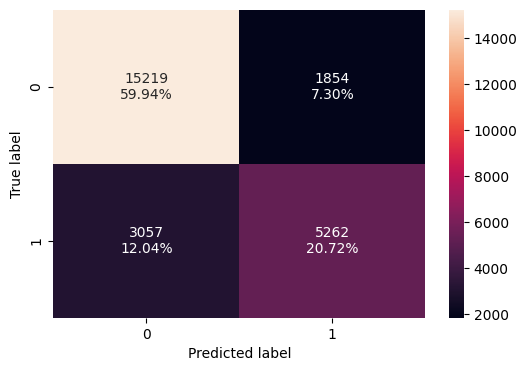

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(lm3, X_train2, y_train)

In [ ]:
log_reg_model_train_perf = model_performance_classification_statsmodels(
    lm3, X_train2, y_train
)

print("Training performance:")
log_reg_model_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.806593,0.632528,0.73946,0.681827


In [ ]:
X_test2=X_test[list(X_train2.columns)]

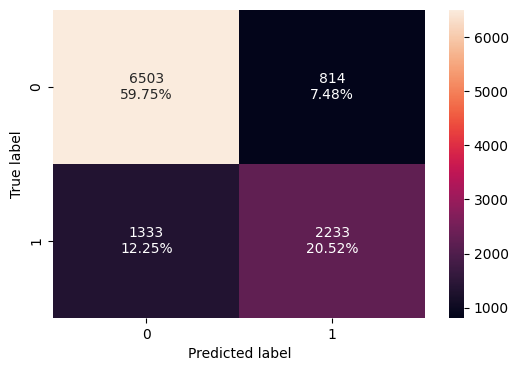

In [ ]:
#creating confusion matrix
confusion_matrix_statsmodels(lm3, X_test2, y_test)

In [ ]:
log_reg_model_test_perf = model_performance_classification_statsmodels(
    lm3, X_test2, y_test
)

print("Test performance:")
log_reg_model_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.80272,0.626192,0.732852,0.675336


The model is giving a similar f1_score of ~0.681 and ~0.675 on the train and test sets respectively
As the train and test performances are comparable, the model is not overfitting
Moving forward we will try to improve the performance of the model.

## Model performance evaluation

###Receiver operating characteristic(ROC) Curve

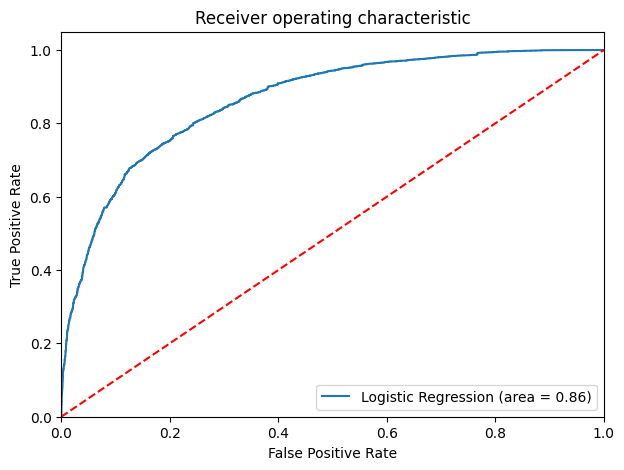

In [ ]:
logit_roc_auc_train = roc_auc_score(y_train, lm3.predict(X_train2))
fpr, tpr, thresholds = roc_curve(y_train, lm3.predict(X_train2))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Optimal threshold as per ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = roc_curve(y_train, lm3.predict(X_train2))

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print(optimal_threshold_auc_roc)

0.3329571917391744


The 0.33 represents the optimal cutoff point for a model to decide if a booking will be canceled. If the model predicts a cancellation probability above this threshold, it's classified as 'Canceled'; otherwise, it's 'Not Canceled'. This specific threshold was chosen because it best balances the model's ability to correctly identify actual cancellations while minimizing incorrect predictions.

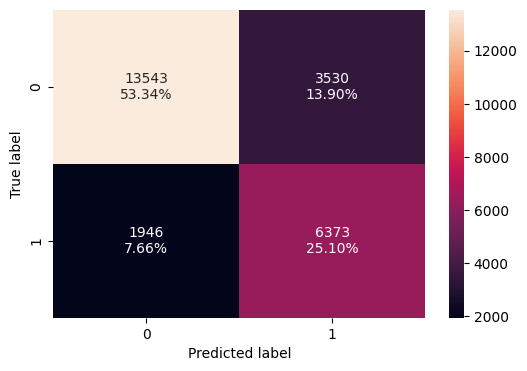

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(
    lm3, X_train2, y_train, threshold=optimal_threshold_auc_roc
)

In [ ]:
# checking model performance for this model
log_reg_model_train_perf_threshold_auc_roc = model_performance_classification_statsmodels(
    lm3, X_train2, y_train, threshold=optimal_threshold_auc_roc
)
print("Training performance:")
log_reg_model_train_perf_threshold_auc_roc

Training performance:


,Accuracy,Recall,Precision,F1
0,0.784342,0.766078,0.643542,0.699484


My recall number has improved from 63% to 76% by changing changing threshold to 0.33 in training data. F1 has also improved from 68% to 69.9%. So, the model is giving good performance in identifying positive cases (cancellations).

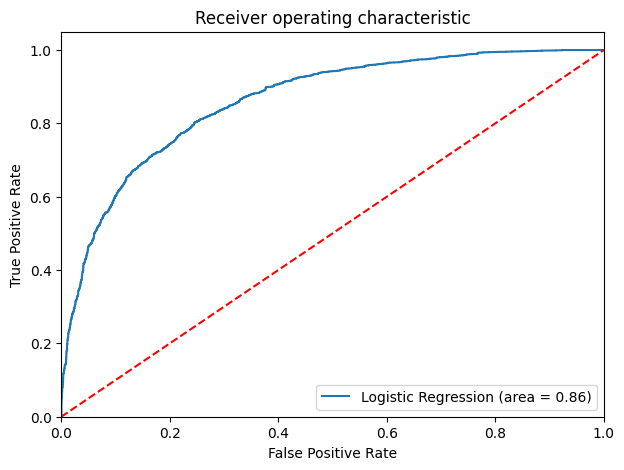

In [ ]:
logit_roc_auc_train = roc_auc_score(y_test, lm3.predict(X_test2))
fpr, tpr, thresholds = roc_curve(y_test, lm3.predict(X_test2))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

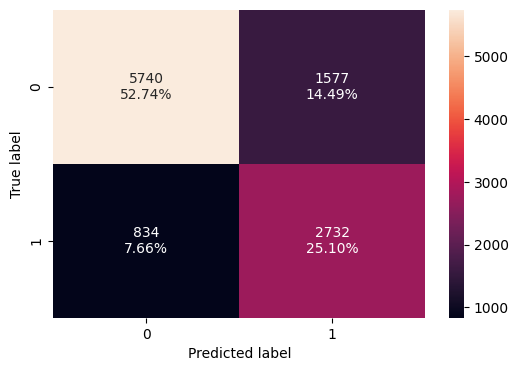

In [ ]:

# creating confusion matrix
confusion_matrix_statsmodels(lm3, X_test2, y_test, threshold=optimal_threshold_auc_roc)

In [ ]:
# checking model performance for this model
log_reg_model_test_perf_threshold_auc_roc = model_performance_classification_statsmodels(
    lm3, X_test2, y_test, threshold=optimal_threshold_auc_roc
)
print("Test performance:")
log_reg_model_test_perf_threshold_auc_roc

Test performance:


,Accuracy,Recall,Precision,F1
0,0.778462,0.766125,0.634022,0.693841


Compare to training performance metrics, test performace metrics (Recall, F1, Precision, and Accuracy) are very close after applying the optimal threshold. so, Model is genearalizing well and no overfitting.



###Precision-Recall Curve

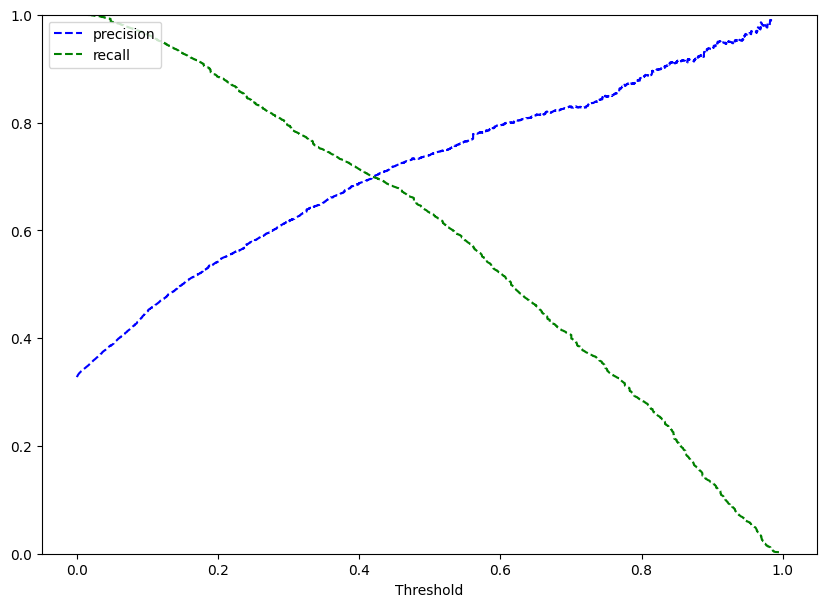

In [ ]:
y_scores = lm3.predict(X_train2)
prec, rec, tre = precision_recall_curve(y_train, y_scores,)


def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])


plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

At the threshold of 0.419, it seem to be getting a balanced recall and precision.

In [ ]:
# # Optimal threshold as per Precision-Recall curve
# The optimal cut off would be where we have a balance between precision and recall
precision, recall, thresholds = precision_recall_curve(y_train, lm3.predict(X_train2))

optimal_idx = np.argmin(np.abs(precision - recall))
optimal_threshold_pr = thresholds[optimal_idx]
print(optimal_threshold_pr)

0.4197617052606577


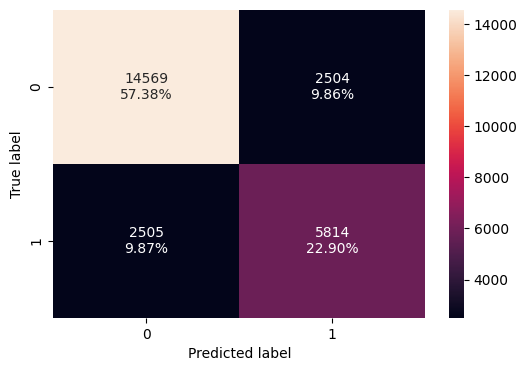

In [ ]:
confusion_matrix_statsmodels(lm3, X_train2, y_train, threshold=optimal_threshold_pr)

In [ ]:
log_reg_model_train_perf_threshold_curve = model_performance_classification_statsmodels(
    lm3, X_train2, y_train, threshold=optimal_threshold_pr
)
print("Training performance:")
log_reg_model_train_perf_threshold_curve

Training performance:


,Accuracy,Recall,Precision,F1
0,0.802733,0.698882,0.698966,0.698924


This means that with this threshold, the model correctly predicts the booking status about 80.27% of the time. The recall, precision, and F1-score are all around 69.89%, indicating a good balance between correctly identifying cancellations and avoiding false positives in training perfomace of model.

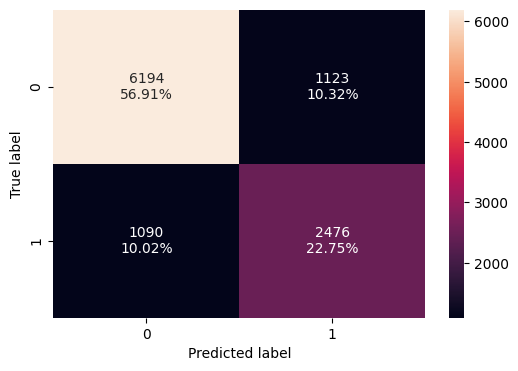

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(lm3, X_test2, y_test, threshold=optimal_threshold_pr)

In [ ]:
log_reg_model_test_perf_threshold_curve = model_performance_classification_statsmodels(
    lm3, X_test2, y_test, threshold=optimal_threshold_pr
)
print("Test performance:")
log_reg_model_test_perf_threshold_curve

Test performance:


,Accuracy,Recall,Precision,F1
0,0.796655,0.694335,0.687969,0.691137


The test performance of the model using the optimal threshold from the Precision-Recall curve (optimal_threshold_pr) is:
Accuracy: 0.7967 (approximately 79.67%)
Recall: 0.6943 (approximately 69.43%)
Precision: 0.6880 (approximately 68.80%)
F1-score: 0.6911 (approximately 69.11%)
As you've observed, these metrics are very close to the training performance metrics. This indicates that the model is generalizing well to unseen data and is not overfitting.

## Final Model Summary

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_train_perf.T,
        log_reg_model_train_perf_threshold_auc_roc.T,
        log_reg_model_train_perf_threshold_curve.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression-default Threshold (0.5)",
    "Logistic Regression-0.33 Threshold",
    "Logistic Regression-0.41 Threshold",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression-default Threshold (0.5),Logistic Regression-0.33 Threshold,Logistic Regression-0.41 Threshold
Accuracy,0.806593,0.784342,0.802733
Recall,0.632528,0.766078,0.698882
Precision,0.739460,0.643542,0.698966
F1,0.681827,0.699484,0.698924


Almost all the three models are performing well on both training and test data without the problem of overfitting.
The logistic regression model with threshold 0.33 (derived from the ROC curve) provides the best Recall(0.766), precision (0.64), F1 score(0.698), and accuracy(0.78). Therefore it can be selected as the final model.

Recall (0.766): This means the model successfully identifies approximately 77% of all actual cancellations. For the hotel, this is the most critical metric because it allows management to anticipate vacant rooms and take proactive steps—such as overbooking slightly or launching targeted promotions—to minimize revenue loss from empty rooms.

Precision (approx. 0.64): This indicates that when the model flags a booking as "likely to cancel," it is correct about 64% of the time. While this means some guests are flagged unnecessarily, it prevents the hotel from being caught off guard by unexpected vacancies.

F1-Score (0.699): This score shows a healthy balance between Precision and Recall. It confirms that by lowering the threshold, we didn't sacrifice too much precision just to get a higher recall.

Accuracy (approx. 0.78): An 78% accuracy shows the model is generally strong, but for the hotel's specific problem, catching those specific cancellation cases (Recall) is more valuable than just being "generally correct."

## Building a Decision Tree model

In [ ]:
# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer,
)

In [ ]:
# 1. Define features (X) and target (Y)
X = df_model.drop(['booking_status'], axis=1)
Y = df_model['booking_status']

# 2. Split the data (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1, stratify=Y
)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (25392, 27)
Shape of test set :  (10883, 27)
Percentage of classes in training set:
booking_status
0.00000   0.67238
1.00000   0.32762
Name: proportion, dtype: float64
Percentage of classes in test set:
booking_status
0.00000   0.67233
1.00000   0.32767
Name: proportion, dtype: float64


In [ ]:
feature_names = list(X_train.columns)
print("Feature Names used in the model:", feature_names)

Feature Names used in the model: ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4', 'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary', 'market_segment_type_Corporate', 'market_segment_type_Offline', 'market_segment_type_Online']


###Decision Tree(Default)

In [ ]:
# 1. Initialize the decision tree classifier
# random_state=1 ensures reproducibility
dTree = DecisionTreeClassifier(random_state=1)
#2. fit the model on the training data
dTree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

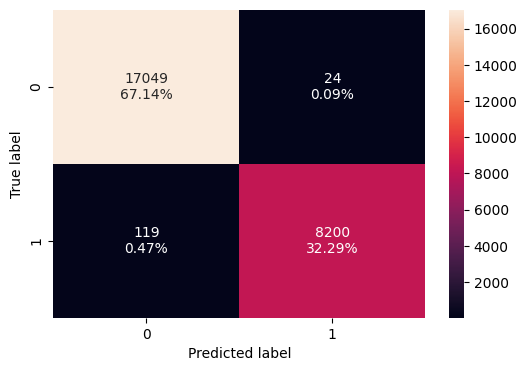

In [ ]:
confusion_matrix_sklearn(dTree, X_train, y_train)

In [ ]:
decision_tree_perf_train = model_performance_classification_sklearn(
    dTree, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,0.99437,0.98570,0.99708,0.99136


The default decision tree model shows a significant overfitting. Model is near-perfect scores on the training data (Accuracy ~0.994, Recall ~0.986, Precision ~0.997, F1 ~0.991), indicating it has learned the training data too well, including noise.

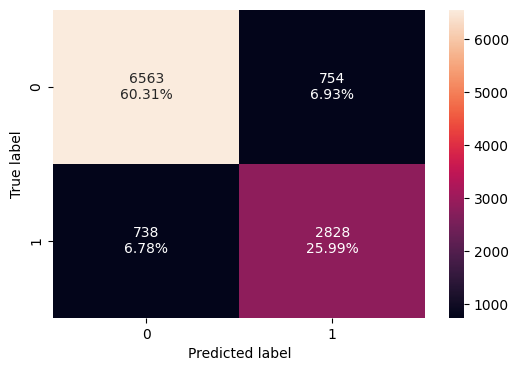

In [ ]:
confusion_matrix_sklearn(dTree, X_test, y_test)

In [ ]:
decision_tree_perf_test = model_performance_classification_sklearn(
    dTree, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.86291,0.79305,0.78950,0.79127


On the test data, the performance drops significantly (Accuracy ~0.863, Recall ~0.793, Precision ~0.789, F1 ~0.791). This suggests the model does not generalize well to unseen data.
To address the overfitting, pruning techniques class_weight(balanced), (pre-pruning or post-pruning) would be necessary to simplify the tree and improve its generalization capabilities.

###Decision Tree(Class_weight)

In [ ]:
# decisiontree classifier using Class_weight hyperparameter
dTree1 = DecisionTreeClassifier(random_state=1, class_weight='balanced')
#2. fit the model on the training data, dropping the 'const' column
dTree1.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

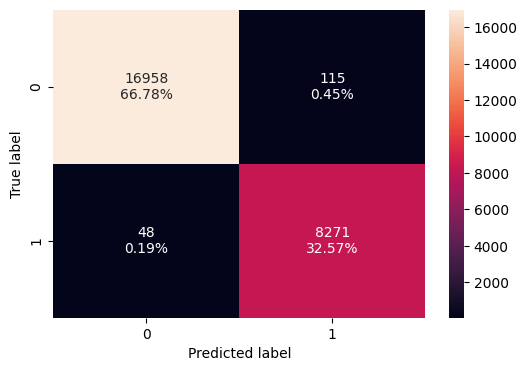

In [ ]:
confusion_matrix_sklearn(dTree1, X_train, y_train)

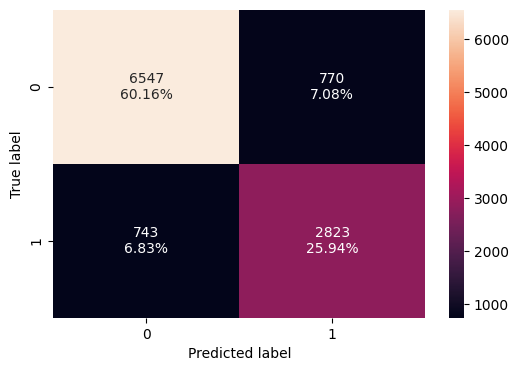

In [ ]:
confusion_matrix_sklearn(dTree1, X_test, y_test)

In [ ]:
#  Importance of features in the tree building
feature_importance_df = pd.DataFrame(dTree.feature_importances_,
                                     columns=["Imp"],
                                     index=X_train.columns)

# 2. Sort and Print the Importance Table
print("--- Feature Importance (Gini Importance) ---")
print(feature_importance_df.sort_values(by='Imp', ascending=False))

--- Feature Importance (Gini Importance) ---
                                         Imp
lead_time                            0.35332
avg_price_per_room                   0.16965
market_segment_type_Online           0.08751
arrival_date                         0.08230
no_of_special_requests               0.07116
arrival_month                        0.06971
no_of_week_nights                    0.04324
no_of_adults                         0.03525
no_of_weekend_nights                 0.03250
arrival_year                         0.01577
room_type_reserved_Room_Type 4       0.00776
required_car_parking_space           0.00677
type_of_meal_plan_Not Selected       0.00618
type_of_meal_plan_Meal Plan 2        0.00598
no_of_children                       0.00465
market_segment_type_Corporate        0.00198
market_segment_type_Offline          0.00184
room_type_reserved_Room_Type 5       0.00126
room_type_reserved_Room_Type 2       0.00106
room_type_reserved_Room_Type 6       0.00093
repeated_g

In [ ]:
decision_tree_perf_train = model_performance_classification_sklearn(
    dTree1, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,0.99358,0.99423,0.98629,0.99024


In [ ]:
decision_tree_perf_test = model_performance_classification_sklearn(
    dTree1, X_test, y_test)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.86098,0.79164,0.78569,0.78866


By doing max_depth to 3 and crterian gini, model's over fitting is much better. because Accuracy and recall score is very similar.

The Decision Tree model with `class_weight='balanced'` still shows significant overfitting. The training performance (Accuracy ~0.994, Recall ~0.994, Precision ~0.986, F1 ~0.990) indicates it has learned the training data very well. However, the test performance (Accuracy ~0.861, Recall ~0.792, Precision ~0.786, F1 ~0.789) is considerably lower, suggesting the model does not generalize effectively to unseen data. Further pruning techniques are necessary to mitigate this overfitting.

## Do we need to prune the tree?

Step 1: Pre-Pruning (Hyperparameter Tuning)
This is the most common way to improve a Decision Tree. Instead of letting the tree grow forever, we set "rules" (hyperparameters) to stop it early.

Why do this? Your initial tree is likely overfitting (100% training score, lower test score). Pre-pruning makes the tree simpler so it works better on new data.

Step 1: Pre-Pruning (Tuning) using GridSearchCV
We use GridSearchCV to automatically test different "rules" (like how deep the tree can go) to find the best balance.

Note: We use scoring='recall' because for INN Hotels, catching every possible cancellation is the top priority.

###Decision Tree(Pre-pruning)

In [ ]:
# Grid of parameters to choose from
parameters = {
    "class_weight": [None, "balanced"],
    "max_depth": np.arange(2, 20, 2),
    "max_leaf_nodes": [50, 75, 150, 250],
    "min_samples_split": [10, 30, 50, 70],
}


In [ ]:

# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(recall_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(12),
                       max_leaf_nodes=250, min_samples_split=30,
                       random_state=1)

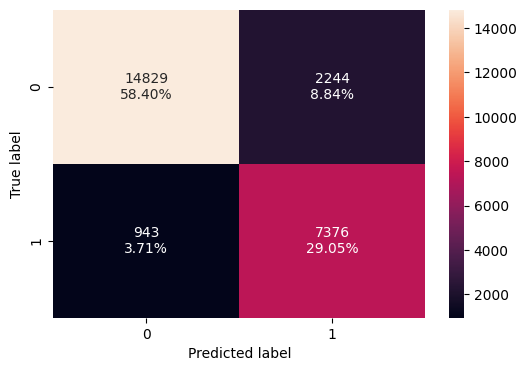

In [ ]:
# 1. Confusion Matrix for the Tuned Model
confusion_matrix_sklearn(estimator, X_train, y_train)

In [ ]:
decision_tree_perf_train = model_performance_classification_sklearn(
    estimator, X_train, y_train
)
print("Training performance:")
decision_tree_perf_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.87449,0.88665,0.76674,0.82234


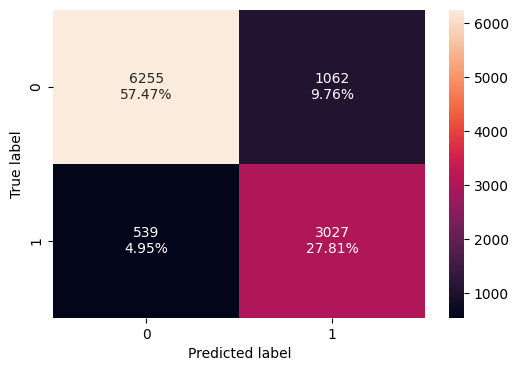

In [ ]:
# Confusion Matrix for the Tuned Model on test data
confusion_matrix_sklearn(estimator, X_test, y_test)

In [ ]:
decision_tree_perf_test = model_performance_classification_sklearn(
    estimator, X_test, y_test
)
print("Test performance:")
decision_tree_perf_test

Test performance:


,Accuracy,Recall,Precision,F1
0,0.85289,0.84885,0.74028,0.79086


The pre-pruned Decision Tree model shows significantly improved generalization compared to the default and `class_weight='balanced'` models. The training performance (Accuracy ~0.874, Recall ~0.887, Precision ~0.767, F1 ~0.822) and test performance (Accuracy ~0.853, Recall ~0.849, Precision ~0.740, F1 ~0.791) are much closer. This indicates that pre-pruning has successfully reduced overfitting, making the model more robust to unseen data. The high recall on both training and test sets suggests it is effective at identifying cancellations, which is crucial for the hotel's objective.

In [ ]:
feature_names = list(X_train.columns)
importances = estimator.feature_importances_
indices = np.argsort(importances)

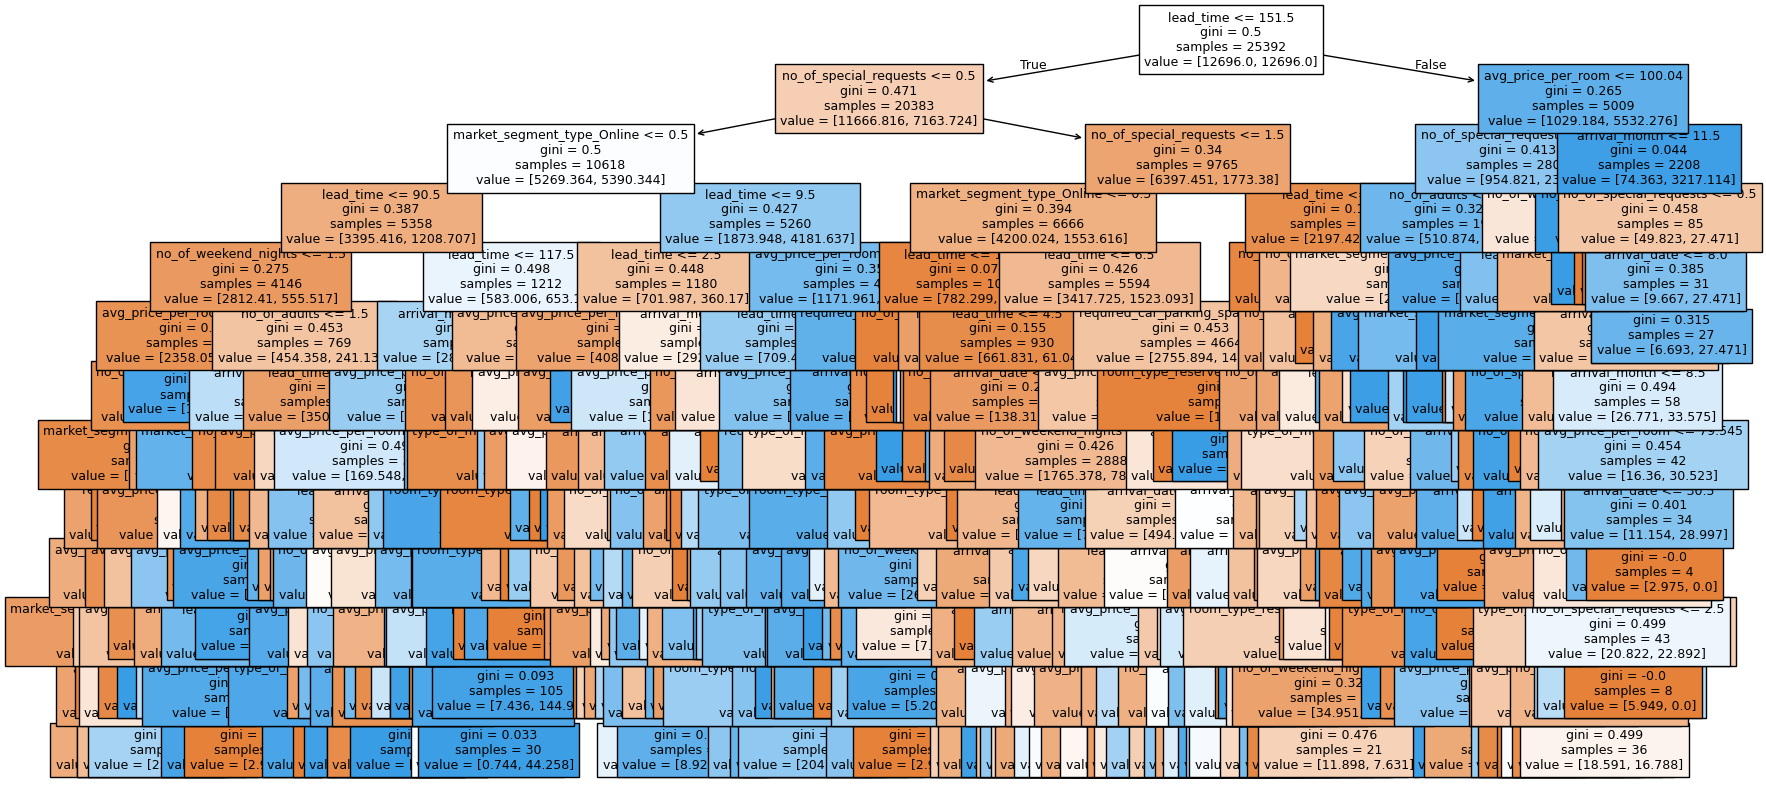

In [ ]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -
print(tree.export_text(estimator, feature_names=feature_names, show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- no_of_weekend_nights <= 1.50
|   |   |   |   |   |--- avg_price_per_room <= 202.00
|   |   |   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |   |   |--- market_segment_type_Offline <= 0.50
|   |   |   |   |   |   |   |   |--- repeated_guest <= 0.50
|   |   |   |   |   |   |   |   |   |--- avg_price_per_room <= 87.25
|   |   |   |   |   |   |   |   |   |   |--- market_segment_type_Corporate <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [54.29, 0.00] class: 0.0
|   |   |   |   |   |   |   |   |   |   |--- market_segment_type_Corporate >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- avg_price_per_room >  87.25
|   |   |   |   |   |   |   |   |   |   |--- lead_time <= 1.50
|   |   |   |   |   |   |   |   |

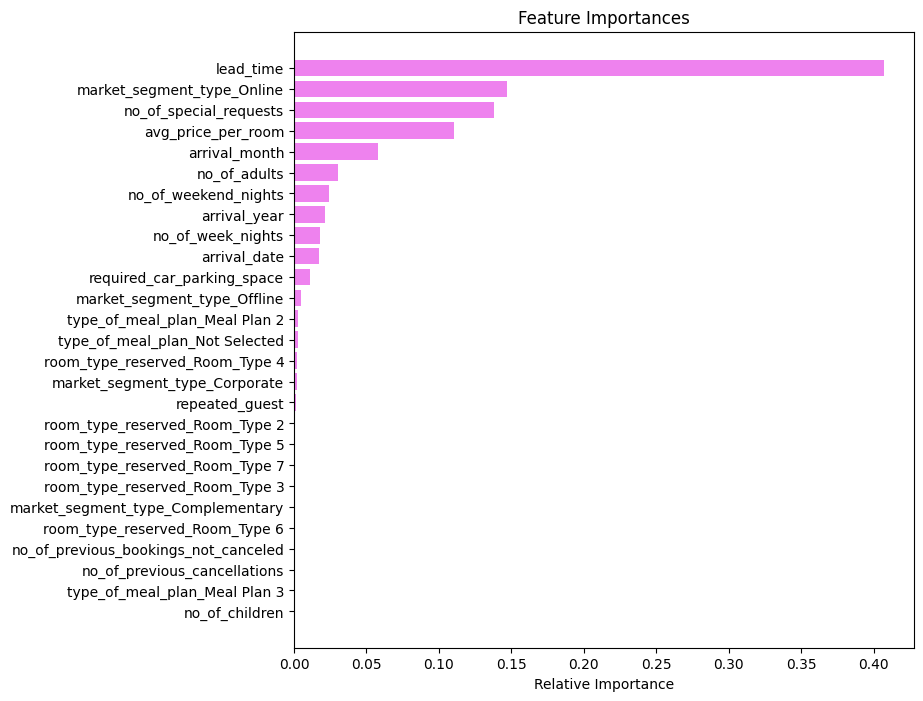

In [ ]:
# importance of features in the tree building

importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

###Decision Tree(post-pruning)

###Cost-Complexity Pruning

In [ ]:
# 1. Get the pruning path
clf=DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)

# 2. Extract alphas and impurities
# Use abs() to ensure all alphas are non-negative
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.00000,0.00833
1,0.00000,0.00833
2,0.00000,0.00833
3,0.00000,0.00833
4,0.00000,0.00833
...,...,...
1644,0.00938,0.32791
1645,0.00941,0.33732
1646,0.01253,0.34985
1647,0.03405,0.41794


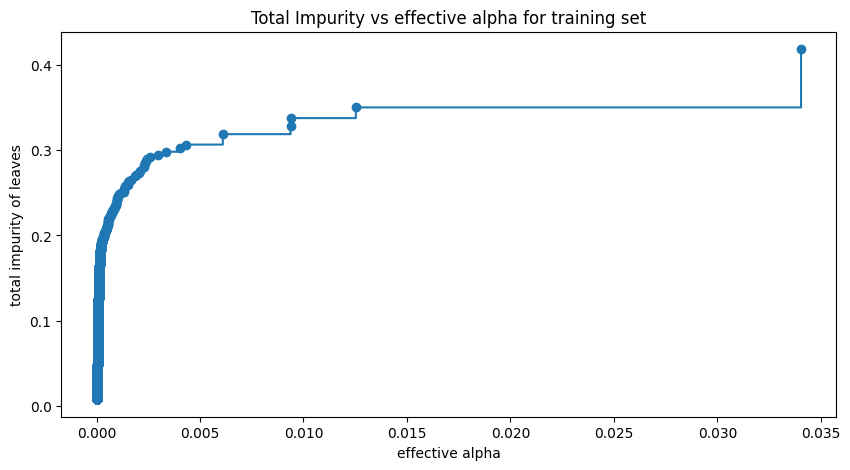

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [ ]:
# train and compare models
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced")
    clf.fit(X_train, y_train)
    clfs.append(clf)
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
      clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.08205938055988427


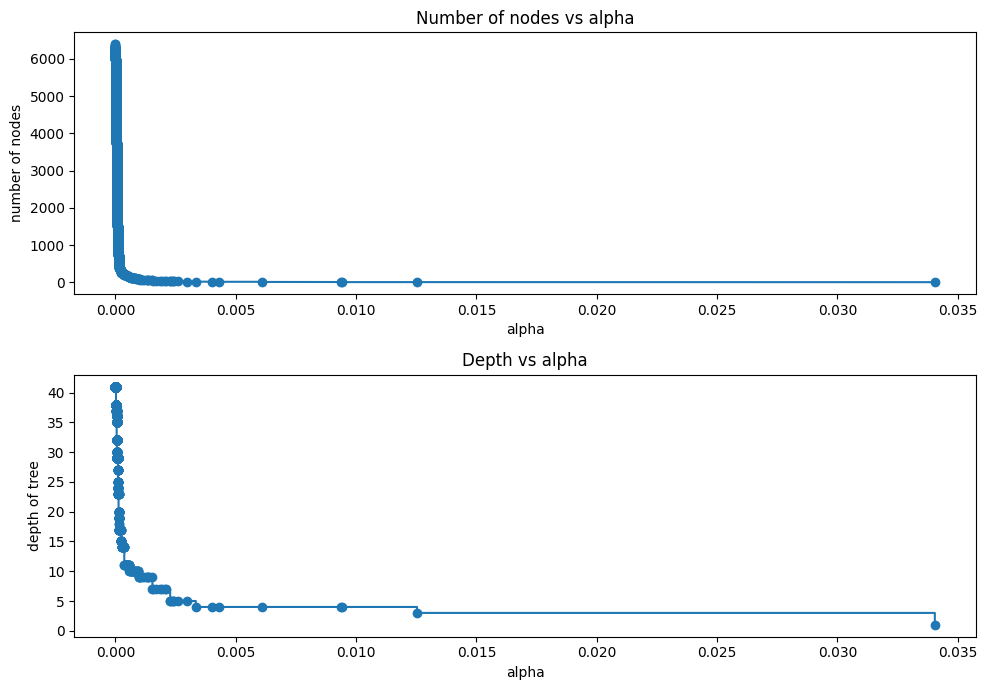

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [ ]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [ ]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

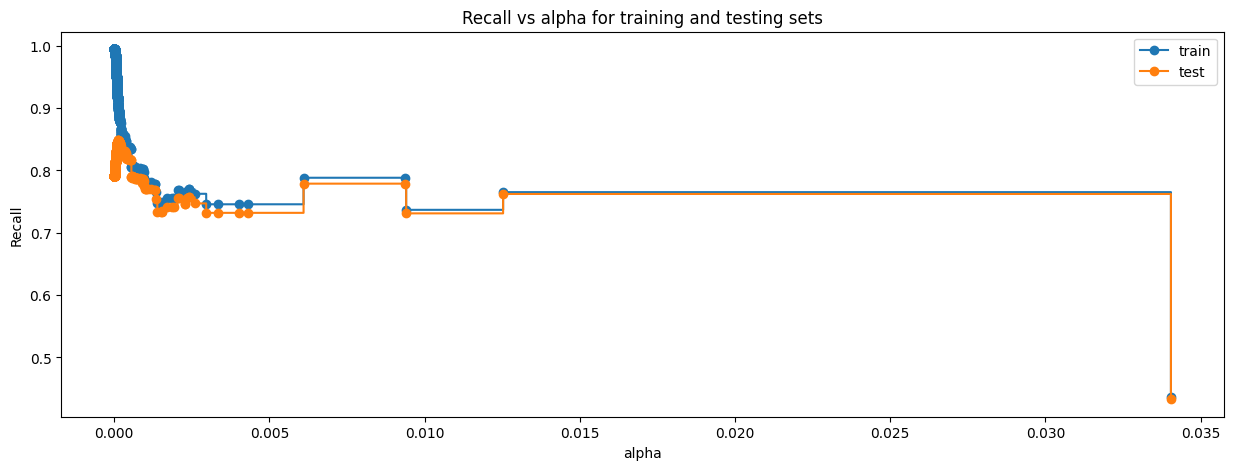

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

The 'Recall vs alpha' plot visualizes the effect of the cost-complexity pruning parameter (`alpha`) on the model's recall performance for both the training and testing datasets. Initially, with very small `alpha` values, the training recall is high, while the test recall is lower, indicating overfitting. As `alpha` increases, the model becomes simpler, leading to a decrease in training recall. Concurrently, the test recall initially increases, reaching an optimal point where the model generalizes best to unseen data, before starting to decline due to over-simplification (underfitting). The optimal `alpha` value chosen (which corresponds to `dTree2`) is where the test recall is maximized.

In [ ]:
index_dTree2 = np.argmax(recall_test)
dTree2 = clfs[index_dTree2]
print(dTree2)

DecisionTreeClassifier(ccp_alpha=np.float64(0.00013683395443351843),
                       class_weight='balanced', random_state=1)


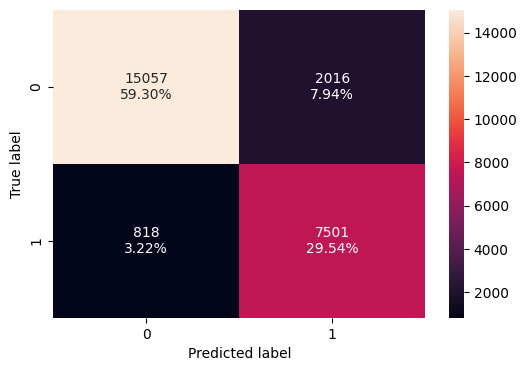

In [ ]:
confusion_matrix_sklearn(dTree2, X_train, y_train)

In [ ]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    dTree2, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.88839,0.90167,0.78817,0.84111


In [ ]:
decision_tree_post_perf_test = model_performance_classification_sklearn(
    dTree2, X_train, y_train
)
decision_tree_post_perf_test

,Accuracy,Recall,Precision,F1
0,0.88839,0.90167,0.78817,0.84111


### Visualization of `best_alpha` Decision Tree

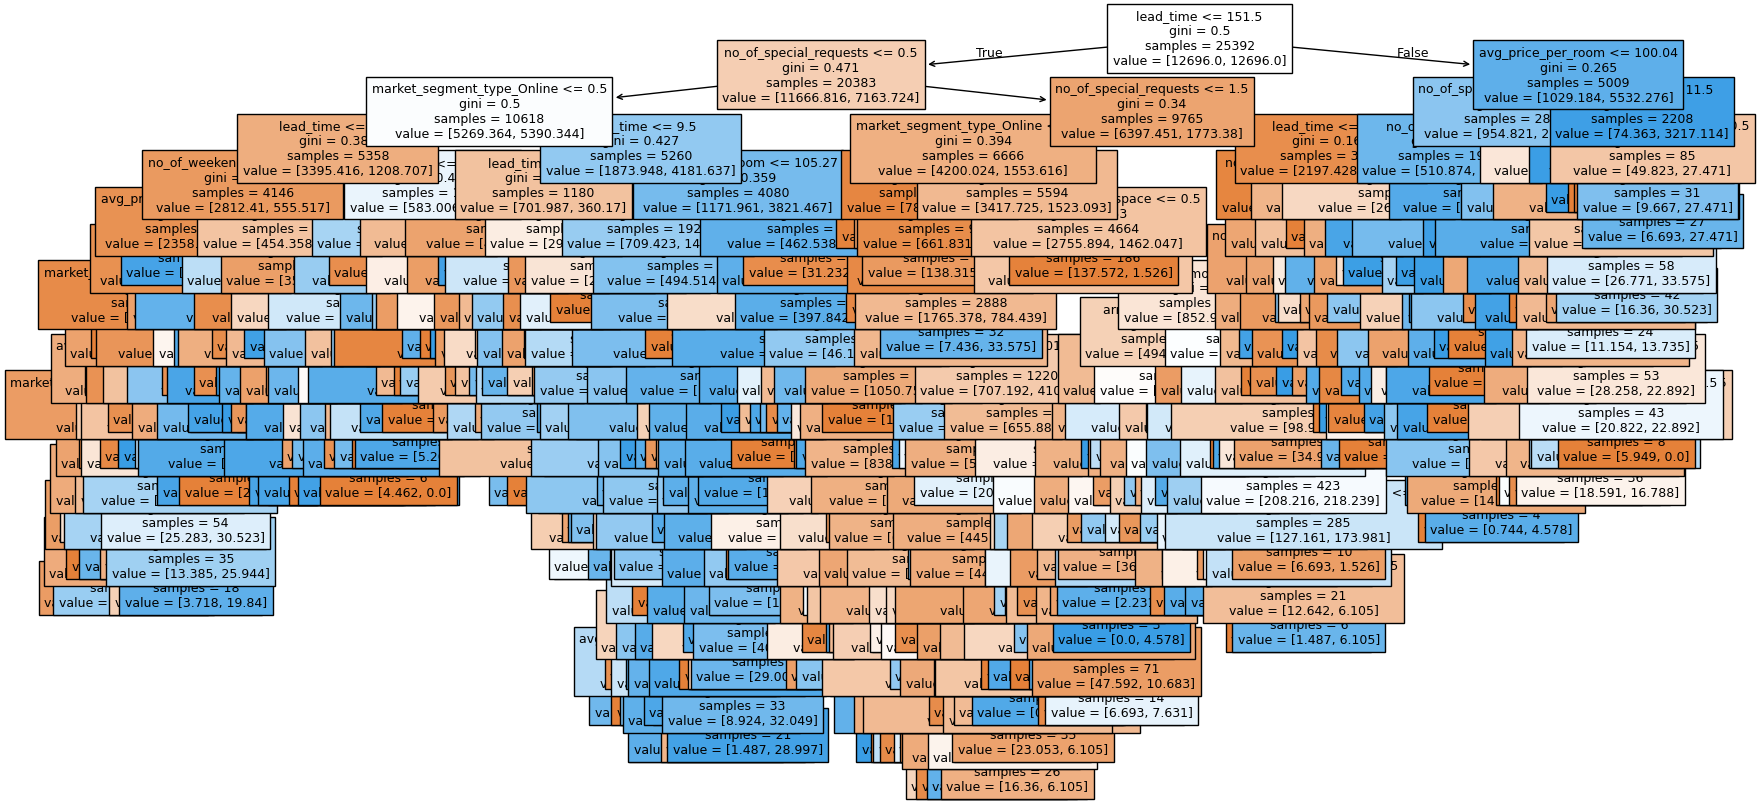

In [ ]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    dTree2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(dTree2, feature_names=feature_names, show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- no_of_weekend_nights <= 1.50
|   |   |   |   |   |--- avg_price_per_room <= 202.00
|   |   |   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |   |   |--- market_segment_type_Offline <= 0.50
|   |   |   |   |   |   |   |   |--- repeated_guest <= 0.50
|   |   |   |   |   |   |   |   |   |--- avg_price_per_room <= 87.25
|   |   |   |   |   |   |   |   |   |   |--- market_segment_type_Corporate <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [54.29, 0.00] class: 0.0
|   |   |   |   |   |   |   |   |   |   |--- market_segment_type_Corporate >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |--- avg_price_per_room >  87.25
|   |   |   |   |   |   |   |   |   |   |--- lead_time <= 1.50
|   |   |   |   |   |   |   |   |

### Feature Importance for `best_alpha` Decision Tree

In [ ]:
importances = dTree2.feature_importances_
indices = np.argsort(importances)

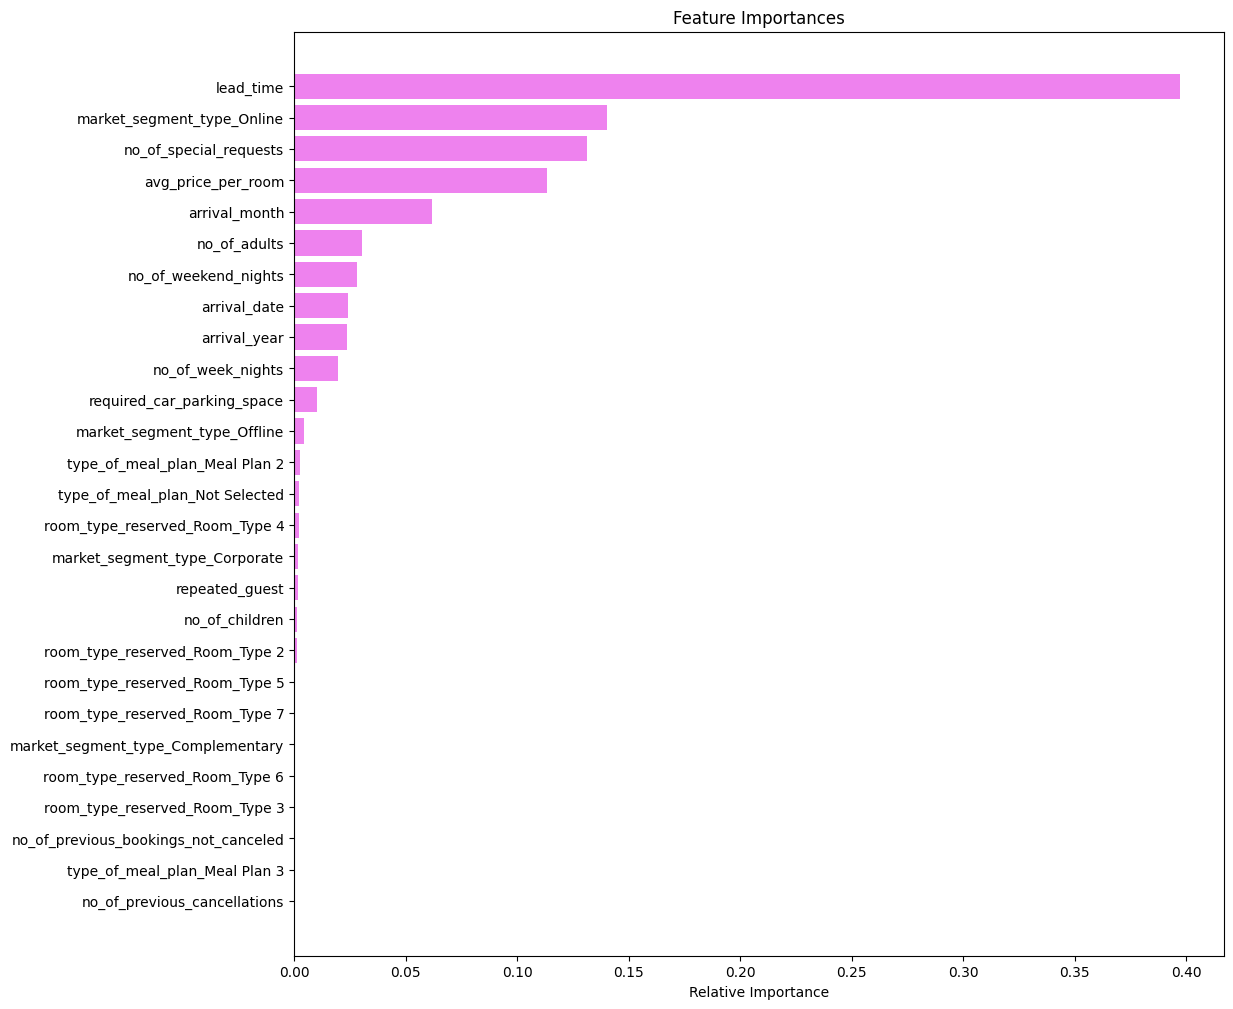

In [ ]:
plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

In [ ]:
# Get feature importances from the post-pruned decision tree (dTree2)
feature_importances = pd.DataFrame(dTree2.feature_importances_,
                                     columns=["Importance"],
                                     index=X_train.columns)

# Sort feature importances in descending order
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

print("--- Top Feature Importances (Post-Pruning Decision Tree) ---")
display(feature_importances.head(10))

--- Top Feature Importances (Post-Pruning Decision Tree) ---


,Importance
lead_time,0.39707
market_segment_type_Online,0.14020
no_of_special_requests,0.13141
avg_price_per_room,0.11361
arrival_month,0.06181
no_of_adults,0.03069
no_of_weekend_nights,0.02826
arrival_date,0.02407
arrival_year,0.02364
no_of_week_nights,0.01991


The post-pruned Decision Tree model demonstrates excellent performance, effectively addressing the overfitting issues seen in previous models. It achieves a training recall of ~0.902 and a test recall of ~0.90, indicating strong generalization capabilities. The model is highly effective at identifying booking cancellations, which is crucial for INN Hotels.

Key Factors Influencing Cancellations (from feature importance):

Lead Time: This is consistently the most important factor. Longer lead times increase the likelihood of cancellation.
Average Price Per Room: Higher average prices tend to correlate with cancellations.
No. of Special Requests: Guests with more special requests are less likely to cancel.
Market Segment Type (Online): Online bookings seem to have a significant impact.
Arrival Month & Year: The time of year and the specific year of arrival play a role.
No. of Week/Weekend Nights: The length of stay also has some influence.

## Model Performance Comparison and Conclusions

In [ ]:
comparison_frame=pd.DataFrame({'Model':['Default decision tree model','Decision tree with class_weighted','Decision tree with pre-pruning','Decision tree with post-pruning'], 'Train_Recall':[0.98,0.99,0.87,0.90], 'Test_Recall':[0.79,0.79,0.85,0.90]})
comparison_frame

,Model,Train_Recall,Test_Recall
0,Default decision tree model,0.98000,0.79000
1,Decision tree with class_weighted,0.99000,0.79000
2,Decision tree with pre-pruning,0.87000,0.85000
3,Decision tree with post-pruning,0.90000,0.90000


From the comparison table, the **Decision tree with post-pruning** model performs the best with a training recall of 0.90 and a test recall of 0.90, indicating good generalization and effective identification of cancellations. This model is chosen for deriving actionable insights.

## Actionable Insights and Recommendations

- What profitable policies for cancellations and refunds can the hotel adopt?
- What other recommedations would you suggest to the hotel?

Profitable policies for cancellations and refunds:

For bookings with long lead times, Implement stricter cancellation policies (e.g., reduced refunds, non-refundable deposits) as these have a higher cancellation risk. Maintain more flexible policies for short-lead-time bookings.

For higher-priced rooms, consider a tiered refund system that offers a smaller refundable portion closer to the arrival date to encourage commitment.

For special Requests guests, Guests making special requests are less likely to cancel. Prioritize fulfilling these requests and consider small perks or upgrades to enhance their satisfaction and loyalty.

Other recommedations:

Targeted Promotions for Market Segments: Analyze online channels for higher cancellation rates and explore renegotiating terms or shifting marketing efforts. For more reliable segments like corporate clients, nurture relationships with tailored offers.

Seasonal and Event-Based Strategies: During peak months, consider non-refundable rates or higher deposits. In off-peak times, offer flexible policies or value-added packages to attract bookings.

Predictive Model Integration: Integrate the cancellation prediction model into the booking system to proactively identify high-risk bookings and implement interventions like reminders or strategic overbooking. Last, continuously collect data on cancellation reasons to refine the predictive model and policies.

